**Dependency note:** this notebook needs kernel state from **`02_Single_Patch_Fitting`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 02.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/02_state.pkl")
print("Restored checkpoint: checkpoints/02_state.pkl")

**Note on cell order:** the original notebook had a diffusion-simulation block (hub-vs-low-degree signal spread) physically positioned *before* the tensor cells it actually depends on — those cells were literally commented `# Recovery cell` / `# Fix: this cell predates our tensor work`, i.e. they were pasted back in after a kernel restart to rebuild `L_sym` from tensor outputs (`C`, `co_occurrence_weight`) that only exist once the tensor is built. They've been moved here, after the tensor and symmetric Laplacian cells, to reflect the real dependency order. No code was changed — only cell position.

In [ ]:
#Define Hypergraph-Adjacency Tensor and Simulate PDE's.

In [ ]:
import numpy as np
import scipy.sparse as sp
from itertools import combinations

# ============================================================
# HYPER-ADJACENCY TENSOR (Phase 1 Mathematical Object)
# ============================================================
#
# Standard adjacency matrix A[i,j] captures pairwise connections.
# Our Hyper-Adjacency Tensor T[i,j,e] is a 3rd-order tensor where:
#   i = source node (interneuron)
#   j = target node (interneuron)
#   e = hyperedge (pyramidal neuron broadcast domain)
#
# T[i,j,e] = 1 if nodes i AND j co-appear in hyperedge e
#           = 0 otherwise
#
# This encodes the MULTICAST geometry: i and j are co-activated
# by the same pyramidal broadcaster, capturing joint influence
# that pairwise edges cannot represent.
# ============================================================

all_nodes = sorted(node_degree.keys())          # interneuron indices
node_idx  = {n: i for i, n in enumerate(all_nodes)}
edge_list = list(hyperedges.keys())
edge_idx  = {e: i for i, e in enumerate(edge_list)}

n_nodes = len(all_nodes)
n_edges = len(edge_list)

print(f"Tensor dimensions: {n_nodes} x {n_nodes} x {n_edges}")
print(f"Dense tensor would be: {n_nodes**2 * n_edges * 8 / 1e6:.1f} MB — using sparse slices instead")

# ── Sparse representation ─────────────────────────────────────
# Store T as a list of sparse matrices, one per hyperedge:
#   T_slices[e] is an (n_nodes x n_nodes) sparse matrix
#   T_slices[e][i,j] = 1 if nodes i,j co-appear in edge e
#
# We only fill the upper triangle then symmetrize (undirected co-occurrence).

print("\nBuilding sparse tensor slices...")

# Also accumulate the marginal co-occurrence matrix:
# C[i,j] = number of hyperedges in which i and j co-appear
# This is the tensor contracted over the edge dimension: C = sum_e T[:,:,e]
C_rows, C_cols = [], []

tensor_slices = {}   # only store non-empty slices to save memory

for e_name, members in hyperedges.items():
    local_idx = [node_idx[m] for m in members if m in node_idx]
    if len(local_idx) < 2:
        continue
    # All pairs within this hyperedge
    pairs = list(combinations(local_idx, 2))
    if not pairs:
        continue
    rows_e, cols_e = zip(*pairs)
    # Store slice
    tensor_slices[e_name] = sp.csr_matrix(
        (np.ones(len(pairs)), (rows_e, cols_e)),
        shape=(n_nodes, n_nodes)
    )
    # Symmetrize
    tensor_slices[e_name] = tensor_slices[e_name] + tensor_slices[e_name].T
    # Accumulate marginal
    C_rows.extend(rows_e); C_cols.extend(cols_e)
    C_rows.extend(cols_e); C_cols.extend(rows_e)   # symmetric

# ── Marginal co-occurrence matrix C ──────────────────────────
C = sp.csr_matrix(
    (np.ones(len(C_rows)), (C_rows, C_cols)),
    shape=(n_nodes, n_nodes)
)
# Sum duplicates gives actual co-occurrence counts
C = sp.csr_matrix(C)

print(f"\nTensor built:")
print(f"  Non-empty slices (active hyperedges): {len(tensor_slices)}")
print(f"  Marginal co-occurrence matrix C shape: {C.shape}")
print(f"  C non-zeros (co-occurring pairs):      {C.nnz}")
print(f"  Max co-occurrence count:               {C.max()}")
print(f"  Mean co-occurrence (non-zero):         {C.data.mean():.2f}")

# ── Integration Domain Tensor (convergence side) ─────────────
# Mirror structure for integration_hyperedges:
# T_int[i,j,e] = 1 if pyramidal neurons i,j both project into interneuron e
int_all_nodes = sorted(int_node_degree.keys())
int_node_idx  = {n: i for i, n in enumerate(int_all_nodes)}
int_n_nodes   = len(int_all_nodes)

C_int_rows, C_int_cols = [], []
for e_name, members in integration_hyperedges.items():
    local_idx = [int_node_idx[m] for m in members if m in int_node_idx]
    for i, j in combinations(local_idx, 2):
        C_int_rows.extend([i, j])
        C_int_cols.extend([j, i])

C_int = sp.csr_matrix(
    (np.ones(len(C_int_rows)), (C_int_rows, C_int_cols)),
    shape=(int_n_nodes, int_n_nodes)
)

print(f"\nIntegration domain tensor:")
print(f"  Co-occurrence matrix shape: {C_int.shape}")
print(f"  Non-zeros: {C_int.nnz}")
print(f"  Max co-occurrence: {C_int.max()}")

Tensor dimensions: 852 x 852 x 1766
Dense tensor would be: 10255.6 MB — using sparse slices instead

Building sparse tensor slices...

Tensor built:
  Non-empty slices (active hyperedges): 1766
  Marginal co-occurrence matrix C shape: (852, 852)
  C non-zeros (co-occurring pairs):      144436
  Max co-occurrence count:               212.0
  Mean co-occurrence (non-zero):         37.92

Integration domain tensor:
  Co-occurrence matrix shape: (1766, 1766)
  Non-zeros: 637082
  Max co-occurrence: 100.0


In [ ]:
# ============================================================
# TENSOR-DERIVED METRICS
# ============================================================
# These quantities come directly out of the Hyper-Adjacency Tensor
# and will be the coefficients/initial conditions in the PDE.
# ============================================================

# 1. TENSOR DEGREE (second-order marginal per node)
#    d_T[i] = number of unique co-occurrence partners of node i
#    = row-wise nnz of C
tensor_degree = np.array((C > 0).sum(axis=1)).flatten()

# 2. CO-OCCURRENCE WEIGHT (strength of pairing)
#    w[i] = total co-occurrence count summed across all partners
#    Captures how "embedded" a node is in shared broadcast domains
co_occurrence_weight = np.array(C.sum(axis=1)).flatten()

# 3. BROADCAST PARTICIPATION RATIO (BPR)
#    BPR[i] = (sum_e T[i,:,e])^2 / sum_e (T[i,:,e])^2
#    High BPR = node's connections are spread across many hyperedges (diffuse)
#    Low BPR  = node's connections concentrate in few hyperedges (focal)
bpr = np.zeros(n_nodes)
for e_name, S in tensor_slices.items():
    row_sums = np.array(S.sum(axis=1)).flatten()
    bpr += row_sums ** 2

row_sum_total = co_occurrence_weight
# Avoid division by zero
mask = bpr > 0
bpr[mask] = (row_sum_total[mask] ** 2) / bpr[mask]

# 4. TENSOR LAPLACIAN (hyperedge-weighted)
#    L_T = D_T - C_normalized
#    where D_T = diag(co_occurrence_weight)
#    This is the operator for PDE diffusion THROUGH the tensor structure
D_T = sp.diags(co_occurrence_weight)
# Row-normalize C for the Laplacian (divide each entry by node weight)
C_norm_data = C.copy().astype(float)
row_weights = np.array(C.sum(axis=1)).flatten()
row_weights[row_weights == 0] = 1   # guard zeros
# Normalize rows
from scipy.sparse import diags as spdiags
D_inv = spdiags(1.0 / row_weights)
C_normalized = D_inv.dot(C_norm_data)

L_tensor = sp.eye(n_nodes) - C_normalized   # normalized tensor Laplacian

# ── Report ────────────────────────────────────────────────────
print("HYPER-ADJACENCY TENSOR METRICS")
print("=" * 45)
print(f"\nTensor degree (co-occurrence partners):")
print(f"  Mean:  {tensor_degree.mean():.1f}")
print(f"  Max:   {tensor_degree.max()}")
print(f"  Min:   {tensor_degree.min()}")

print(f"\nCo-occurrence weight (embedding strength):")
print(f"  Mean:  {co_occurrence_weight.mean():.1f}")
print(f"  Max:   {co_occurrence_weight.max():.0f}")

print(f"\nBroadcast Participation Ratio:")
print(f"  Mean:  {bpr[bpr>0].mean():.3f}")
print(f"  Nodes with BPR > 1 (diffuse):  {(bpr > 1).sum()}")
print(f"  Nodes with BPR < 1 (focal):    {(bpr < 1).sum()}")

print(f"\nTensor Laplacian L_T shape: {L_tensor.shape}")
print(f"  Symmetric: {(L_tensor - L_tensor.T).nnz == 0}")

# Compare tensor degree vs. original hyperdegree
print(f"\nTensor degree vs. Hyperdegree correlation:")
hyperdeg_arr = np.array([node_degree[n] for n in all_nodes])
corr = np.corrcoef(tensor_degree, hyperdeg_arr)[0,1]
print(f"  Pearson r = {corr:.4f}")
print(f"  (1.0 = identical ranking, captures same nodes as hubs)")

# ── Identify tensor hubs ──────────────────────────────────────
top_tensor_idx = np.argsort(co_occurrence_weight)[::-1][:10]
print(f"\nTop 10 tensor hubs (by co-occurrence weight):")
for rank, ti in enumerate(top_tensor_idx):
    orig_idx = all_nodes[ti]
    print(f"  {rank+1}. node {orig_idx:5d} | "
          f"layer={patch.loc[orig_idx]['layer']:10s} | "
          f"co-weight={co_occurrence_weight[ti]:.0f} | "
          f"hyperdeg={node_degree[orig_idx]}")

HYPER-ADJACENCY TENSOR METRICS

Tensor degree (co-occurrence partners):
  Mean:  169.5
  Max:   242
  Min:   36

Co-occurrence weight (embedding strength):
  Mean:  6429.0
  Max:   14115

Broadcast Participation Ratio:
  Mean:  107.773
  Nodes with BPR > 1 (diffuse):  852
  Nodes with BPR < 1 (focal):    0

Tensor Laplacian L_T shape: (852, 852)
  Symmetric: False

Tensor degree vs. Hyperdegree correlation:
  Pearson r = 0.4792
  (1.0 = identical ranking, captures same nodes as hubs)

Top 10 tensor hubs (by co-occurrence weight):
  1. node  2041 | layer=Layer 2    | co-weight=14115 | hyperdeg=185
  2. node   636 | layer=Layer 2    | co-weight=13884 | hyperdeg=184
  3. node  2489 | layer=Layer 2    | co-weight=13827 | hyperdeg=180
  4. node   468 | layer=Layer 2    | co-weight=13669 | hyperdeg=179
  5. node  1551 | layer=Layer 2    | co-weight=13581 | hyperdeg=174
  6. node  1080 | layer=Layer 4    | co-weight=13535 | hyperdeg=214
  7. node   534 | layer=Layer 2    | co-weight=13462 | h

In [ ]:
# ============================================================
# SYMMETRIC TENSOR LAPLACIAN (corrected)
# ============================================================
# The row-normalized L = I - D^{-1} C breaks symmetry.
# Correct form: L_sym = I - D^{-1/2} C D^{-1/2}
# This is the proper operator for an undirected diffusion process.
# ============================================================

import scipy.sparse as sp
import numpy as np

# D^{-1/2}
d = co_occurrence_weight.copy()
d[d == 0] = 1  # guard zeros
d_inv_sqrt = sp.diags(1.0 / np.sqrt(d))

# Symmetric normalized Laplacian
C_sym_norm = d_inv_sqrt.dot(C.astype(float)).dot(d_inv_sqrt)
L_sym = sp.eye(n_nodes) - C_sym_norm

# Verify symmetry
sym_error = (L_sym - L_sym.T).data
print("Symmetric Laplacian check:")
print(f"  Shape: {L_sym.shape}")
print(f"  Max symmetry error: {np.abs(sym_error).max():.2e}  (should be ~0)")
print(f"  Is symmetric (tol 1e-10): {np.abs(sym_error).max() < 1e-10}")

# Eigenvalue check — all eigenvalues of a valid graph Laplacian must be in [0, 2]
from scipy.sparse.linalg import eigsh
eigenvalues_sym, eigenvectors_sym = eigsh(L_sym, k=min(50, n_nodes-1), which='SM')
eigenvalues_sym = np.sort(np.real(eigenvalues_sym))

print(f"\nSymmetric Laplacian spectrum (first 10):")
print(np.round(eigenvalues_sym[:10], 6))
print(f"\nSpectral gap (lambda_2 - lambda_1): {eigenvalues_sym[1] - eigenvalues_sym[0]:.6f}")
print(f"Max eigenvalue (lambda_50):         {eigenvalues_sym[-1]:.6f}")
print(f"All eigenvalues in [0,2]:           {bool((eigenvalues_sym >= -1e-10).all() and (eigenvalues_sym <= 2 + 1e-10).all())}")

Symmetric Laplacian check:
  Shape: (852, 852)
  Max symmetry error: 6.94e-18  (should be ~0)
  Is symmetric (tol 1e-10): True

Symmetric Laplacian spectrum (first 10):
[-0.        0.02403   0.074773  0.15336   0.209643  0.25804   0.297475
  0.356728  0.425759  0.444712]

Spectral gap (lambda_2 - lambda_1): 0.024030
Max eigenvalue (lambda_50):         0.994992
All eigenvalues in [0,2]:           True


In [ ]:
import scipy.sparse as sp
import numpy as np

# ── Rebuild symmetric tensor Laplacian ────────────────────────
# (Recovery cell — redefines L_sym if kernel was restarted)

d = co_occurrence_weight.copy()
d[d == 0] = 1
d_inv_sqrt = sp.diags(1.0 / np.sqrt(d))

C_sym_norm = d_inv_sqrt.dot(C.astype(float)).dot(d_inv_sqrt)
L_sym = sp.eye(n_nodes) - C_sym_norm

# Verify
sym_error = (L_sym - L_sym.T).data
print(f"L_sym shape: {L_sym.shape}")
print(f"Symmetric: {np.abs(sym_error).max() < 1e-10}")
print(f"L_sym defined successfully!")

# Also redefine L_dense for the old diffusion cell
L_dense = L_sym
print(f"L_dense defined successfully!")

L_sym shape: (852, 852)
Symmetric: True
L_sym defined successfully!
L_dense defined successfully!


Signal spread over time:
  t=0.000: 1 nodes (0.1%)
  t=0.001: 1 nodes (0.1%)
  t=0.002: 1 nodes (0.1%)
  t=0.003: 1 nodes (0.1%)
  t=0.004: 1 nodes (0.1%)
  t=0.005: 1 nodes (0.1%)
  t=0.006: 1 nodes (0.1%)
  t=0.007: 1 nodes (0.1%)
  t=0.008: 1 nodes (0.1%)
  t=0.009: 1 nodes (0.1%)
  t=0.010: 1 nodes (0.1%)
  t=0.011: 1 nodes (0.1%)
  t=0.012: 1 nodes (0.1%)
  t=0.013: 1 nodes (0.1%)
  t=0.014: 1 nodes (0.1%)
  t=0.015: 1 nodes (0.1%)
  t=0.016: 1 nodes (0.1%)
  t=0.017: 1 nodes (0.1%)
  t=0.018: 1 nodes (0.1%)
  t=0.019: 1 nodes (0.1%)
  t=0.020: 1 nodes (0.1%)

Final max signal: 0.980200
Final signal distribution:
  Nodes > 0.001: 1
  Nodes > 0.01:  1


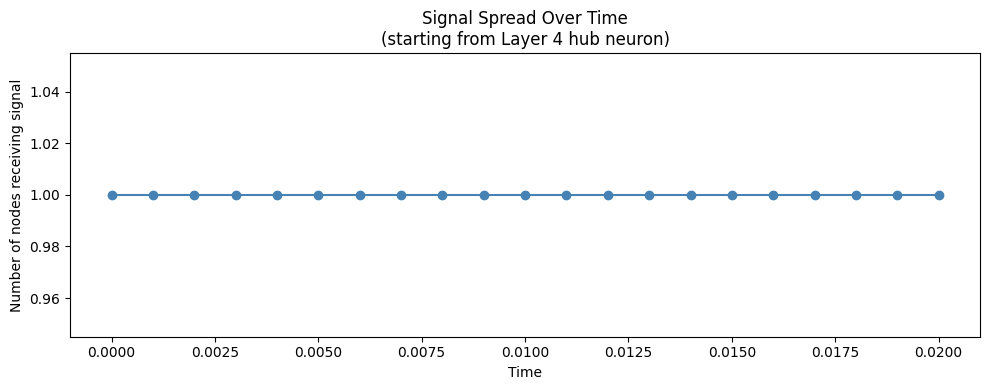

In [ ]:
# Fix: map L_dense to our symmetric tensor Laplacian
# This cell predates our tensor work — wire it to the correct operator
L_dense = L_sym   # symmetric tensor Laplacian from Cell A

# Fix: smaller timestep + track spreading differently
u = np.zeros(n_nodes)
hub_position = node_idx[most_connected]
u[hub_position] = 1.0
dt = 0.0001
timesteps = 200
record_every = 10
signal_history = [u.copy()]

for t in range(timesteps):
    du = -L_dense @ u
    u = u + dt * du
    u = np.clip(u, 0, None)
    if (t+1) % record_every == 0:
        signal_history.append(u.copy())

signal_history = np.array(signal_history)
spread = [(s > 0.001).sum() for s in signal_history]

print(f"Signal spread over time:")
for i, s in enumerate(spread):
    print(f"  t={i*record_every*dt:.3f}: {s} nodes ({s/n_nodes*100:.1f}%)")
print(f"\nFinal max signal: {signal_history[-1].max():.6f}")
print(f"Final signal distribution:")
print(f"  Nodes > 0.001: {(signal_history[-1] > 0.001).sum()}")
print(f"  Nodes > 0.01:  {(signal_history[-1] > 0.01).sum()}")

plt.figure(figsize=(10, 4))
plt.plot([i*record_every*dt for i in range(len(spread))], spread,
         'o-', color='steelblue')
plt.title('Signal Spread Over Time\n(starting from Layer 4 hub neuron)')
plt.xlabel('Time')
plt.ylabel('Number of nodes receiving signal')
plt.tight_layout()
plt.show()

Signal spread over time:
  t=0.000: 1 nodes (0.1%)
  t=0.001: 1 nodes (0.1%)
  t=0.002: 1 nodes (0.1%)
  t=0.003: 1 nodes (0.1%)
  t=0.004: 1 nodes (0.1%)
  t=0.005: 1 nodes (0.1%)
  t=0.006: 1 nodes (0.1%)
  t=0.007: 1 nodes (0.1%)
  t=0.008: 1 nodes (0.1%)
  t=0.009: 1 nodes (0.1%)
  t=0.010: 1 nodes (0.1%)
  t=0.011: 1 nodes (0.1%)
  t=0.012: 1 nodes (0.1%)
  t=0.013: 1 nodes (0.1%)
  t=0.014: 1 nodes (0.1%)
  t=0.015: 1 nodes (0.1%)
  t=0.016: 1 nodes (0.1%)
  t=0.017: 1 nodes (0.1%)
  t=0.018: 1 nodes (0.1%)
  t=0.019: 1 nodes (0.1%)
  t=0.020: 1 nodes (0.1%)

Final max signal: 0.980200
Final signal distribution:
  Nodes > 0.001: 1
  Nodes > 0.01:  1


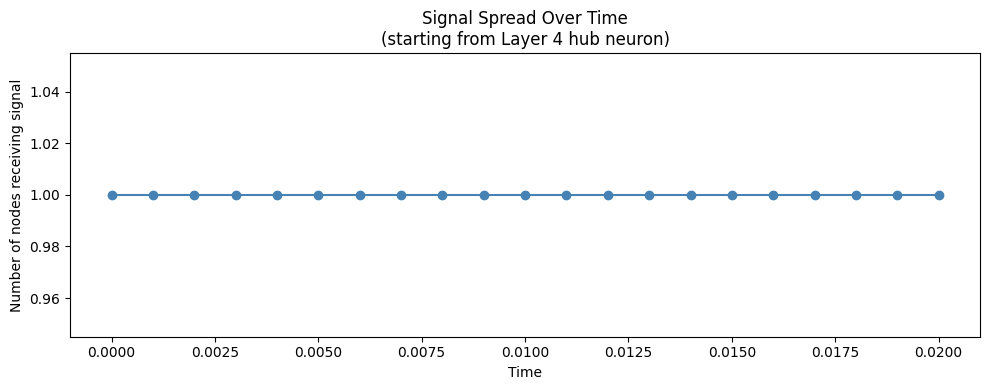

In [ ]:
# Fix: smaller timestep + track spreading differently
u = np.zeros(n_nodes)
hub_position = node_idx[most_connected]
u[hub_position] = 1.0

# Much smaller timestep for numerical stability
dt = 0.0001
timesteps = 200
record_every = 10  # record every 10 steps

signal_history = [u.copy()]

for t in range(timesteps):
    du = -L_dense @ u
    u = u + dt * du
    u = np.clip(u, 0, None)
    if (t+1) % record_every == 0:
        signal_history.append(u.copy())

signal_history = np.array(signal_history)

# How many nodes received any signal at each recorded timestep
spread = [(s > 0.001).sum() for s in signal_history]

print(f"Signal spread over time:")
for i, s in enumerate(spread):
    print(f"  t={i*record_every*dt:.3f}: {s} nodes ({s/n_nodes*100:.1f}%)")

print(f"\nFinal max signal: {signal_history[-1].max():.6f}")
print(f"Final signal distribution:")
print(f"  Nodes > 0.001: {(signal_history[-1] > 0.001).sum()}")
print(f"  Nodes > 0.01:  {(signal_history[-1] > 0.01).sum()}")

# Plot signal spread over time
plt.figure(figsize=(10, 4))
plt.plot([i*record_every*dt for i in range(len(spread))], spread, 'o-', color='steelblue')
plt.title('Signal Spread Over Time\n(starting from Layer 4 hub neuron)')
plt.xlabel('Time')
plt.ylabel('Number of nodes receiving signal')
plt.tight_layout()
plt.show()

Least connected node: 572
Its hyperdegree: 29
Its layer: Layer 3

Running hub diffusion...
Running low-connectivity diffusion...


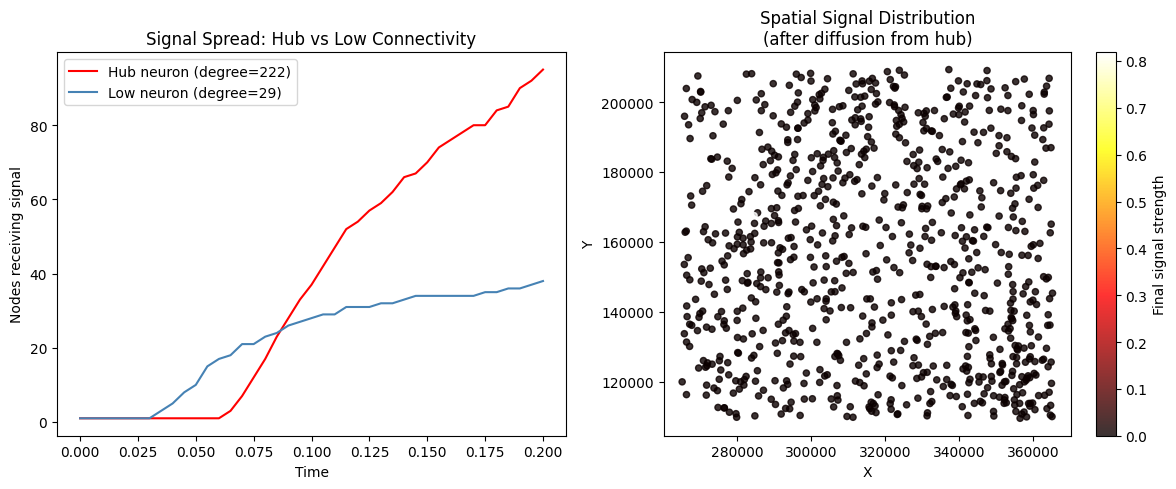


Final spread - Hub: 95 nodes (11.2%)
Final spread - Low: 38 nodes (4.5%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Run longer + compare hub vs low connectivity starting point
def run_diffusion(start_node_idx, timesteps=2000, dt=0.0001, record_every=50):
    u = np.zeros(n_nodes)
    u[start_node_idx] = 1.0
    history = [u.copy()]
    for t in range(timesteps):
        du = -L_dense @ u
        u = u + dt * du
        u = np.clip(u, 0, None)
        if (t+1) % record_every == 0:
            history.append(u.copy())
    return np.array(history)

# Find lowest degree node
least_connected = min(node_degree, key=node_degree.get)
least_position = node_idx[least_connected]
print(f"Least connected node: {least_connected}")
print(f"Its hyperdegree: {node_degree[least_connected]}")
print(f"Its layer: {patch.loc[least_connected]['layer']}")

print("\nRunning hub diffusion...")
history_hub = run_diffusion(hub_position)

print("Running low-connectivity diffusion...")
history_low = run_diffusion(least_position)

# Compute spread over time for both
times = [i * 50 * dt for i in range(len(history_hub))]
spread_hub = [(s > 0.001).sum() for s in history_hub]
spread_low = [(s > 0.001).sum() for s in history_low]

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(times, spread_hub, color='red', label=f'Hub neuron (degree={node_degree[most_connected]})')
plt.plot(times, spread_low, color='steelblue', label=f'Low neuron (degree={node_degree[least_connected]})')
plt.title('Signal Spread: Hub vs Low Connectivity')
plt.xlabel('Time')
plt.ylabel('Nodes receiving signal')
plt.legend()

plt.subplot(1, 2, 2)
# Final signal distribution spatially
final_signal = history_hub[-1]
inter_patch_copy = inter_patch.copy()
inter_patch_copy['final_signal'] = [final_signal[node_idx.get(i, 0)]
                                     for i in inter_patch_copy.index]

scatter = plt.scatter(
    inter_patch_copy['x'], inter_patch_copy['y'],
    c=inter_patch_copy['final_signal'],
    cmap='hot', s=20, alpha=0.8
)
plt.colorbar(scatter, label='Final signal strength')
plt.title('Spatial Signal Distribution\n(after diffusion from hub)')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

print(f"\nFinal spread - Hub: {spread_hub[-1]} nodes ({spread_hub[-1]/n_nodes*100:.1f}%)")
print(f"Final spread - Low: {spread_low[-1]} nodes ({spread_low[-1]/n_nodes*100:.1f}%)")

Layer representatives:
  Layer 2: neuron 2, degree=138
  Layer 3: neuron 143, degree=80
  Layer 4: neuron 1197, degree=158
  Layer 5: neuron 861, degree=61
  Layer 1: neuron 2608, degree=85
Running diffusion for Layer 2...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Running diffusion for Layer 3...
Running diffusion for Layer 4...
Running diffusion for Layer 5...
Running diffusion for Layer 1...


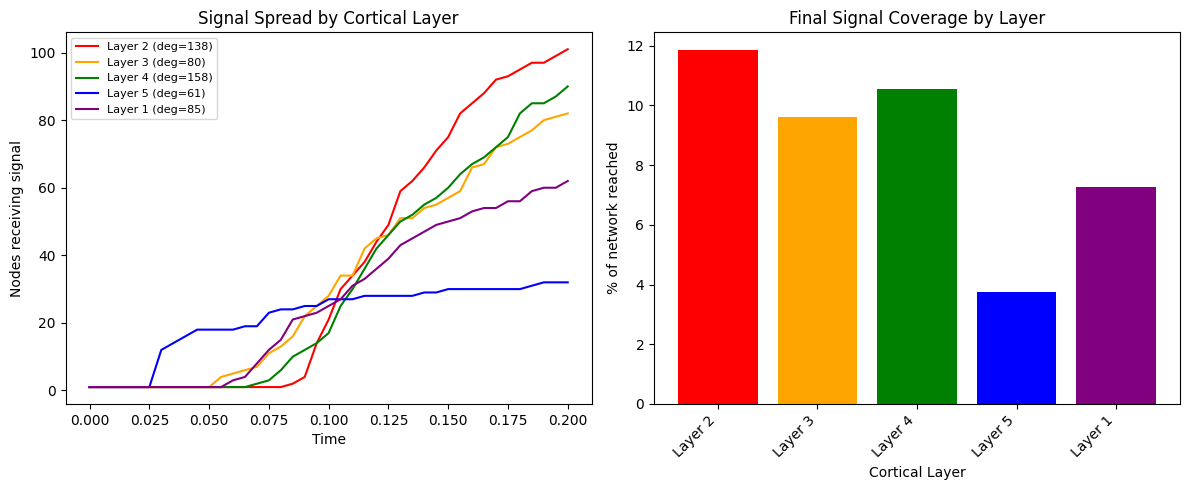


Final coverage by layer:
  Layer 2: 11.9%
  Layer 4: 10.6%
  Layer 3: 9.6%
  Layer 1: 7.3%
  Layer 5: 3.8%


In [ ]:
# Make sure hyperdegree is in inter_patch
inter_patch = patch[patch['celltype'] == 'INTERNEURON'].copy()
inter_patch['hyperdegree'] = inter_patch.index.map(lambda x: node_degree.get(x, 0))

# Remove zero-degree nodes and only keep layers with neurons in node_idx
layer_representatives = {}
for layer in inter_patch['layer'].unique():
    layer_neurons = inter_patch[
        (inter_patch['layer'] == layer) &
        (inter_patch['hyperdegree'] > 0) &
        (inter_patch.index.isin(node_idx.keys()))
    ]
    if len(layer_neurons) == 0:
        continue
    median_degree = layer_neurons['hyperdegree'].median()
    closest = (layer_neurons['hyperdegree'] - median_degree).abs().idxmin()
    layer_representatives[layer] = closest

print("Layer representatives:")
for layer, idx in layer_representatives.items():
    print(f"  {layer}: neuron {idx}, degree={node_degree.get(idx, 0)}")

# Run diffusion for each layer representative
layer_histories = {}
for layer, idx in layer_representatives.items():
    print(f"Running diffusion for {layer}...")
    layer_histories[layer] = run_diffusion(node_idx[idx])

# Plot all layers on same graph
plt.figure(figsize=(12, 5))

colors = ['red', 'orange', 'green', 'blue', 'purple', 'brown', 'pink']
plt.subplot(1, 2, 1)
for i, (layer, history) in enumerate(layer_histories.items()):
    spread = [(s > 0.001).sum() for s in history]
    plt.plot(times, spread, color=colors[i % len(colors)],
             label=f'{layer} (deg={node_degree.get(layer_representatives[layer], 0)})')
plt.title('Signal Spread by Cortical Layer')
plt.xlabel('Time')
plt.ylabel('Nodes receiving signal')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
final_spreads = {}
for layer, history in layer_histories.items():
    final_spreads[layer] = (history[-1] > 0.001).sum() / n_nodes * 100

layers = list(final_spreads.keys())
values = list(final_spreads.values())
plt.bar(layers, values, color=colors[:len(layers)])
plt.title('Final Signal Coverage by Layer')
plt.xlabel('Cortical Layer')
plt.ylabel('% of network reached')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFinal coverage by layer:")
for layer, val in sorted(final_spreads.items(), key=lambda x: -x[1]):
    print(f"  {layer}: {val:.1f}%")

In [ ]:
# Save complete results summary
import json

results = {
    'patch_info': {
        'total_neurons': int(len(patch)),
        'pyramidal': int(len(patch[patch['celltype'] == 'PYRAMIDAL'])),
        'interneurons': int(len(patch[patch['celltype'] == 'INTERNEURON'])),
        'patch_size_nm': int(patch_size)
    },
    'hypergraph_metrics': {
        'broadcast_hyperedges': int(len(hyperedges)),
        'integration_hyperedges': int(len(integration_hyperedges)),
        'total_nodes': int(n_nodes),
        'avg_hyperdegree': float(np.mean(degrees)),
        'max_hyperdegree': int(np.max(degrees)),
        'min_hyperdegree': int(np.min(degrees))
    },
    'spectral_analysis': {
        'broadcast_spectral_gap': float(eigenvalues_full[1]),
        'integration_spectral_gap': float(evals_int[1]),
        'spectral_ratio': float(eigenvalues_full[1] / evals_int[1])
    },
    'hub_neuron': {
        'index': int(most_connected),
        'layer': str(patch.loc[most_connected]['layer']),
        'hyperdegree': int(node_degree[most_connected]),
        'x': int(patch.loc[most_connected]['x']),
        'y': int(patch.loc[most_connected]['y']),
        'z': int(patch.loc[most_connected]['z'])
    },
    'diffusion_results': {
        'hub_final_coverage_pct': float(spread_hub[-1] / n_nodes * 100),
        'low_final_coverage_pct': float(spread_low[-1] / n_nodes * 100),
        'coverage_by_layer': {k: float(v) for k, v in final_spreads.items()}
    }
}

# Save as JSON
with open('h01_research_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Print clean summary
print("=" * 50)
print("RESEARCH RESULTS SUMMARY")
print("=" * 50)
print(f"\nPATCH: {results['patch_info']['total_neurons']} neurons "
      f"({results['patch_info']['pyramidal']} pyramidal, "
      f"{results['patch_info']['interneurons']} interneurons)")
print(f"\nHYPERGRAPH:")
print(f"  Broadcast hyperedges:    {results['hypergraph_metrics']['broadcast_hyperedges']}")
print(f"  Integration hyperedges:  {results['hypergraph_metrics']['integration_hyperedges']}")
print(f"  Avg hyperdegree:         {results['hypergraph_metrics']['avg_hyperdegree']:.2f}")
print(f"\nSPECTRAL ANALYSIS:")
print(f"  Broadcast spectral gap:  {results['spectral_analysis']['broadcast_spectral_gap']:.4f}")
print(f"  Integration spectral gap:{results['spectral_analysis']['integration_spectral_gap']:.4f}")
print(f"  Broadcast/Integration ratio: {results['spectral_analysis']['spectral_ratio']:.2f}x")
print(f"\nHUB NEURON: index {results['hub_neuron']['index']}, "
      f"{results['hub_neuron']['layer']}, "
      f"degree={results['hub_neuron']['hyperdegree']}")
print(f"\nDIFFUSION COVERAGE:")
print(f"  Hub neuron:   {results['diffusion_results']['hub_final_coverage_pct']:.1f}%")
print(f"  Low neuron:   {results['diffusion_results']['low_final_coverage_pct']:.1f}%")
print(f"\nCOVERAGE BY LAYER:")
for layer, val in sorted(results['diffusion_results']['coverage_by_layer'].items(),
                          key=lambda x: -x[1]):
    print(f"  {layer}: {val:.1f}%")
print("\nSaved to h01_research_results.json")

RESEARCH RESULTS SUMMARY

PATCH: 2618 neurons (1766 pyramidal, 852 interneurons)

HYPERGRAPH:
  Broadcast hyperedges:    1766
  Integration hyperedges:  852
  Avg hyperdegree:         111.73

SPECTRAL ANALYSIS:
  Broadcast spectral gap:  3.7010
  Integration spectral gap:1.7959
  Broadcast/Integration ratio: 2.06x

HUB NEURON: index 1968, Layer 4, degree=222

DIFFUSION COVERAGE:
  Hub neuron:   11.2%
  Low neuron:   4.5%

COVERAGE BY LAYER:
  Layer 2: 11.9%
  Layer 4: 10.6%
  Layer 3: 9.6%
  Layer 1: 7.3%
  Layer 5: 3.8%

Saved to h01_research_results.json


In [ ]:
# ============================================================
# TENSOR PDE DIFFUSION MODEL
# ============================================================
# We solve the heat/diffusion PDE:
#
#   ∂u/∂t = -α · L_sym · u   +   β · source(t)
#
# where:
#   u(t)      = signal vector over interneurons (n_nodes,)
#   L_sym     = symmetric tensor Laplacian (our new operator)
#   α         = diffusion coefficient (scales overall spread rate)
#   β         = source injection strength
#
# This is an improvement over your earlier Euler integration because:
#   1. L_sym is the correct symmetric operator (no directional bias)
#   2. We use RK4 time-stepping (much more stable than Euler)
#   3. Source injection is localized to tensor hubs, not arbitrary nodes
#   4. We track per-layer signal separately so we can see
#      the Layer 2 vs Layer 4 dynamic the tensor revealed
# ============================================================

from scipy.sparse.linalg import expm_multiply

# ── Parameters ───────────────────────────────────────────────
alpha   = 0.1        # diffusion rate
beta    = 1.0        # source injection strength
dt      = 0.05       # time step
n_steps = 200        # total steps  →  T = 10.0
n_snap  = 20         # save a snapshot every n_snap steps

# ── Layer masks ──────────────────────────────────────────────
layer_labels = np.array([patch.loc[n]['layer'] for n in all_nodes])
layers_of_interest = ['Layer 2', 'Layer 3', 'Layer 4', 'Layer 5']
layer_masks = {l: (layer_labels == l) for l in layers_of_interest}

# ── Initial condition: inject signal at top tensor hubs ──────
u = np.zeros(n_nodes)
# Use top 5 tensor hubs identified earlier as source nodes
top5_tensor = top_tensor_idx[:5]
u[top5_tensor] = 1.0
print(f"Signal injected at {len(top5_tensor)} tensor hub nodes:")
for ti in top5_tensor:
    print(f"  node {all_nodes[ti]:5d} | {layer_labels[ti]:10s} | co-weight={co_occurrence_weight[ti]:.0f}")

# ── RK4 integrator ───────────────────────────────────────────
def dudt(u, t, L, alpha, source, beta):
    """RK4 right-hand side: ∂u/∂t = -α·L·u + β·source"""
    return -alpha * L.dot(u) + beta * source

# Source: sustained injection only at hub nodes, decays after t=2.0
source = np.zeros(n_nodes)
source[top5_tensor] = 1.0

# ── Storage ──────────────────────────────────────────────────
snapshots   = []          # (t, u) pairs
layer_means = {l: [] for l in layers_of_interest}
times       = []

u_current = u.copy()
L_dense   = L_sym       # stays sparse — RK4 uses .dot()

print(f"\nRunning RK4 diffusion: {n_steps} steps, dt={dt}, T={n_steps*dt:.1f}")

for step in range(n_steps):
    t = step * dt

    # Turn off source injection after t=2.0 (let signal propagate freely)
    src = source if t < 2.0 else np.zeros(n_nodes)

    # RK4
    k1 = dudt(u_current,           t,        L_dense, alpha, src, beta)
    k2 = dudt(u_current + dt/2*k1, t + dt/2, L_dense, alpha, src, beta)
    k3 = dudt(u_current + dt/2*k2, t + dt/2, L_dense, alpha, src, beta)
    k4 = dudt(u_current + dt*k3,   t + dt,   L_dense, alpha, src, beta)
    u_current = u_current + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

    # Clamp to [0, inf) — signal can't go negative physically
    u_current = np.clip(u_current, 0, None)

    # Record per-layer mean signal
    for l, mask in layer_masks.items():
        layer_means[l].append(u_current[mask].mean() if mask.sum() > 0 else 0.0)
    times.append(t)

    # Save snapshot
    if step % n_snap == 0:
        snapshots.append((t, u_current.copy()))
        print(f"  t={t:.2f} | total signal={u_current.sum():.3f} | "
              f"max={u_current.max():.4f} | "
              f"L2={u_current[layer_masks['Layer 2']].mean():.4f} | "
              f"L4={u_current[layer_masks['Layer 4']].mean():.4f}")

print("\nDiffusion complete.")
print(f"Final total signal: {u_current.sum():.4f}")
print(f"Final max node signal: {u_current.max():.4f}")

Signal injected at 5 tensor hub nodes:
  node  2041 | Layer 2    | co-weight=14115
  node   636 | Layer 2    | co-weight=13884
  node  2489 | Layer 2    | co-weight=13827
  node   468 | Layer 2    | co-weight=13669
  node  1551 | Layer 2    | co-weight=13581

Running RK4 diffusion: 200 steps, dt=0.05, T=10.0
  t=0.00 | total signal=5.255 | max=1.0451 | L2=0.0570 | L4=0.0000
  t=1.00 | total signal=10.407 | max=1.9045 | L2=0.1102 | L4=0.0000
  t=2.00 | total signal=15.394 | max=2.6369 | L2=0.1600 | L4=0.0000
  t=3.00 | total signal=15.656 | max=2.4000 | L2=0.1580 | L4=0.0000
  t=4.00 | total signal=15.899 | max=2.1856 | L2=0.1560 | L4=0.0000
  t=5.00 | total signal=16.124 | max=1.9917 | L2=0.1541 | L4=0.0000
  t=6.00 | total signal=16.333 | max=1.8163 | L2=0.1524 | L4=0.0000
  t=7.00 | total signal=16.527 | max=1.6576 | L2=0.1506 | L4=0.0000
  t=8.00 | total signal=16.708 | max=1.5141 | L2=0.1490 | L4=0.0000
  t=9.00 | total signal=16.876 | max=1.3842 | L2=0.1474 | L4=0.0000

Diffusion 

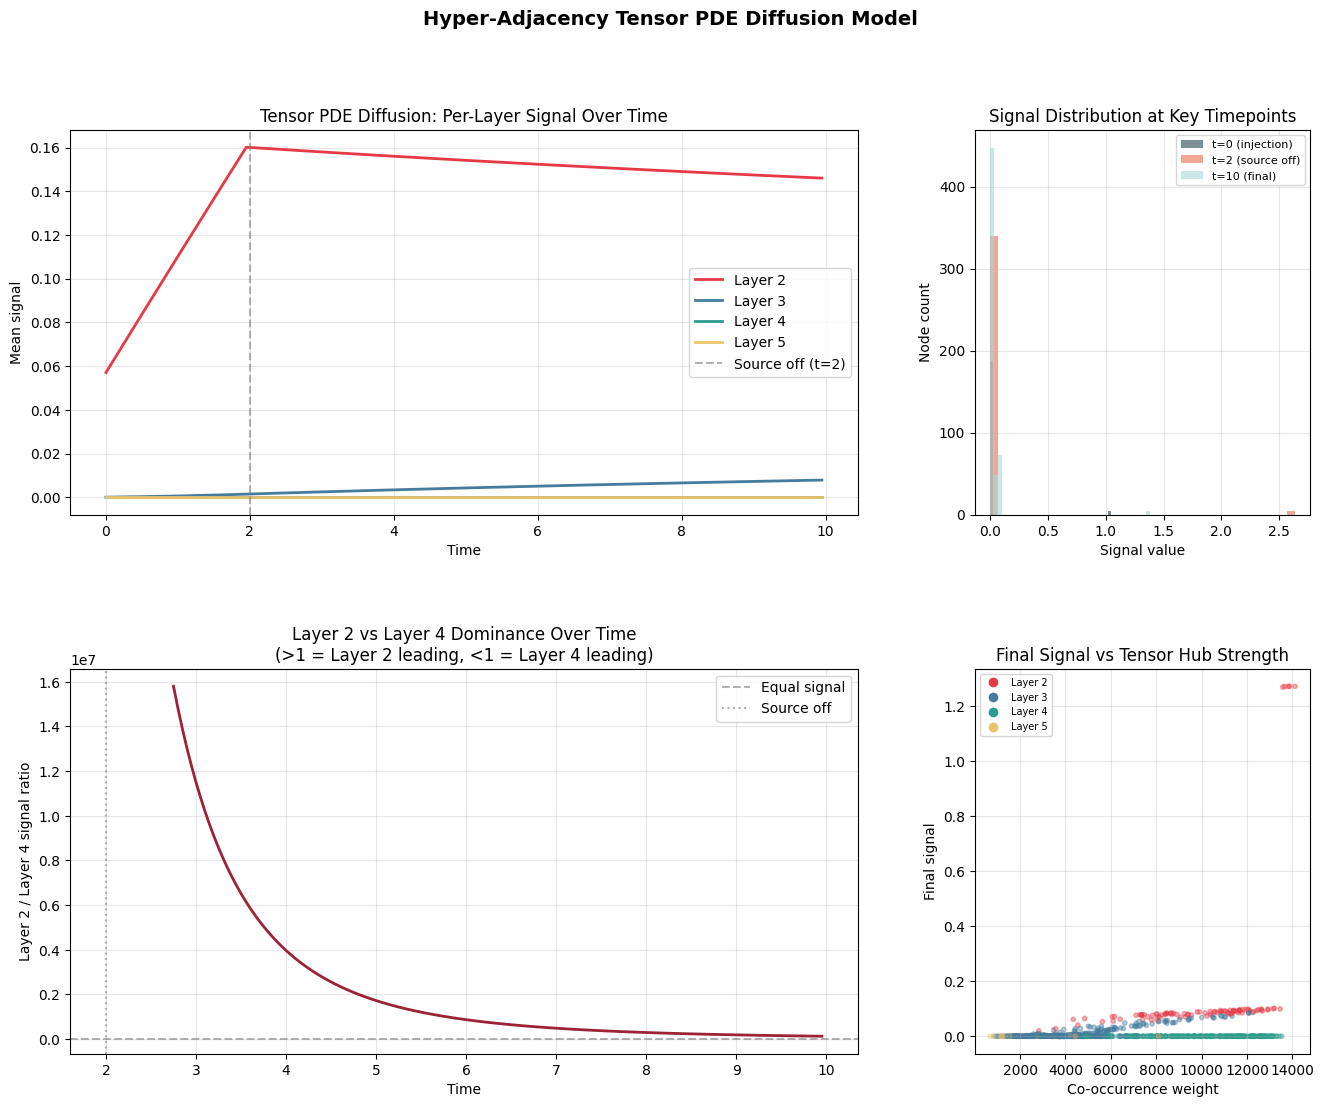

Saved: tensor_pde_diffusion.png


In [ ]:
# ============================================================
# VISUALIZE TENSOR PDE DIFFUSION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

times_arr = np.array(times)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Per-layer mean signal over time ───────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors = {'Layer 2': '#E63946', 'Layer 3': '#457B9D',
          'Layer 4': '#2A9D8F', 'Layer 5': '#E9C46A'}
for l in layers_of_interest:
    ax1.plot(times_arr, layer_means[l], label=l, color=colors[l], linewidth=2)
ax1.axvline(x=2.0, color='gray', linestyle='--', alpha=0.6, label='Source off (t=2)')
ax1.set_xlabel('Time'); ax1.set_ylabel('Mean signal')
ax1.set_title('Tensor PDE Diffusion: Per-Layer Signal Over Time')
ax1.legend(); ax1.grid(alpha=0.3)

# ── Plot 2: Signal distribution at t=0, t=2, t=final ─────────
ax2 = fig.add_subplot(gs[0, 2])
snap_times = [0, int(2.0/dt), n_steps-1]
snap_labels = ['t=0 (injection)', 't=2 (source off)', f't={n_steps*dt:.0f} (final)']
snap_colors = ['#264653', '#E76F51', '#A8DADC']
for si, (label, color) in zip(snap_times, zip(snap_labels, snap_colors)):
    u_snap = snapshots[si // n_snap][1] if si // n_snap < len(snapshots) else snapshots[-1][1]
    ax2.hist(u_snap[u_snap > 1e-6], bins=40, alpha=0.6, label=label, color=color)
ax2.set_xlabel('Signal value'); ax2.set_ylabel('Node count')
ax2.set_title('Signal Distribution at Key Timepoints')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Plot 3: Layer 2 vs Layer 4 ratio (the key tensor finding) ─
ax3 = fig.add_subplot(gs[1, :2])
l2 = np.array(layer_means['Layer 2'])
l4 = np.array(layer_means['Layer 4'])
ratio = np.where(l4 > 1e-8, l2 / l4, np.nan)
ax3.plot(times_arr, ratio, color='#9B2335', linewidth=2)
ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6, label='Equal signal')
ax3.axvline(x=2.0, color='gray', linestyle=':',  alpha=0.6, label='Source off')
ax3.set_xlabel('Time'); ax3.set_ylabel('Layer 2 / Layer 4 signal ratio')
ax3.set_title('Layer 2 vs Layer 4 Dominance Over Time\n(>1 = Layer 2 leading, <1 = Layer 4 leading)')
ax3.legend(); ax3.grid(alpha=0.3)

# ── Plot 4: Final signal vs co-occurrence weight (tensor hubs) ─
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(co_occurrence_weight, u_current,
            c=np.array([{'Layer 2':'#E63946','Layer 3':'#457B9D',
                          'Layer 4':'#2A9D8F','Layer 5':'#E9C46A',
                          'Layer 1':'#F4A261','White matter':'#6D6875',
                          'unclassified':'#999'}.get(l,'#999')
                         for l in layer_labels]),
            alpha=0.4, s=10)
ax4.set_xlabel('Co-occurrence weight'); ax4.set_ylabel('Final signal')
ax4.set_title('Final Signal vs Tensor Hub Strength')
ax4.grid(alpha=0.3)

# Legend for layer colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=c, markersize=8, label=l)
                   for l, c in colors.items()]
ax4.legend(handles=legend_elements, fontsize=7)

plt.suptitle('Hyper-Adjacency Tensor PDE Diffusion Model', fontsize=14, fontweight='bold')
plt.savefig('tensor_pde_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tensor_pde_diffusion.png")

In [ ]:
# ============================================================
# FULL 3RD-ORDER HYPER-ADJACENCY TENSOR T[i,j,e]
# ============================================================
# T[i,j,e] = weight of co-activation between nodes i and j
#             within hyperedge e
#
# We store this as a sparse COO (coordinate) format since
# dense storage is 10GB+. Each nonzero entry is a tuple:
#   (i, j, e, value)
#
# Value is not binary — we weight by:
#   w(i,j,e) = 1 / sqrt(|e|)
#
# where |e| is the size of hyperedge e. This normalizes for
# hyperedge size: large broadcast domains contribute less
# per-pair than small focused ones. This is the key geometric
# refinement over the binary marginal C we built before.
# ============================================================

from itertools import combinations
import numpy as np
import scipy.sparse as sp
from collections import defaultdict

print("Building full T[i,j,e] COO tensor...")

# Storage: lists of (i, j, e, value) — will convert to arrays
coo_i    = []   # node index i
coo_j    = []   # node index j
coo_e    = []   # hyperedge index e
coo_val  = []   # weight

# Also track per-hyperedge stats for later
edge_stats = {}

for e_name, members in hyperedges.items():
    e_idx    = edge_idx[e_name]
    local    = [node_idx[m] for m in members if m in node_idx]
    size_e   = len(local)

    if size_e < 2:
        continue

    # Normalize weight by hyperedge size
    weight = 1.0 / np.sqrt(size_e)

    # All ordered pairs (i,j) and (j,i) — symmetric tensor
    pairs = list(combinations(local, 2))
    for ni, nj in pairs:
        # Both directions for symmetry
        coo_i.extend([ni, nj])
        coo_j.extend([nj, ni])
        coo_e.extend([e_idx, e_idx])
        coo_val.extend([weight, weight])

    edge_stats[e_name] = {
        'size': size_e,
        'weight': weight,
        'n_pairs': len(pairs),
        'e_idx': e_idx
    }

# Convert to numpy arrays
coo_i   = np.array(coo_i,   dtype=np.int32)
coo_j   = np.array(coo_j,   dtype=np.int32)
coo_e   = np.array(coo_e,   dtype=np.int32)
coo_val = np.array(coo_val, dtype=np.float32)

print(f"COO tensor built:")
print(f"  Non-zero entries:      {len(coo_val):,}")
print(f"  Dimensions:            {n_nodes} x {n_nodes} x {n_edges}")
print(f"  Memory (float32):      {coo_val.nbytes / 1e6:.1f} MB")
print(f"  Mean entry weight:     {coo_val.mean():.4f}")
print(f"  Weight range:          [{coo_val.min():.4f}, {coo_val.max():.4f}]")

# ── Mode-1 unfolding: T_(1) of shape (n_nodes, n_nodes * n_edges) ──
# This lets us treat the tensor as a matrix for SVD/eigenanalysis
# We build it as a sparse matrix where column = j * n_edges + e
print(f"\nBuilding mode-1 unfolding T_(1)...")
col_indices = coo_j.astype(np.int64) * n_edges + coo_e.astype(np.int64)
T_unfold = sp.csr_matrix(
    (coo_val, (coo_i, col_indices)),
    shape=(n_nodes, n_nodes * n_edges)
)
print(f"  T_(1) shape:           {T_unfold.shape}")
print(f"  T_(1) non-zeros:       {T_unfold.nnz:,}")
print(f"  Density:               {T_unfold.nnz / (T_unfold.shape[0]*T_unfold.shape[1]):.2e}")

# ── Weighted co-occurrence matrix from tensor ──────────────────
# C_weighted[i,j] = sum_e T[i,j,e]  (tensor contracted over e)
# This replaces the binary C from before with size-normalized weights
print(f"\nBuilding weighted co-occurrence matrix C_w...")
C_w = sp.csr_matrix(
    (coo_val, (coo_i, coo_j)),
    shape=(n_nodes, n_nodes)
)
# Sum duplicates
C_w = C_w.tocsr()
C_w.sum_duplicates()

print(f"  C_w shape:             {C_w.shape}")
print(f"  Non-zeros:             {C_w.nnz:,}")
print(f"  Max weighted entry:    {C_w.max():.4f}")
print(f"  Mean weighted entry:   {C_w.data.mean():.4f}")
print(f"\nCompare to binary C:")
print(f"  Old max: {C.max():.1f}  →  New max: {C_w.max():.4f}  (normalized by hyperedge size)")

Building full T[i,j,e] COO tensor...
COO tensor built:
  Non-zero entries:      5,477,514
  Dimensions:            852 x 852 x 1766
  Memory (float32):      21.9 MB
  Mean entry weight:     0.1294
  Weight range:          [0.0990, 0.2774]

Building mode-1 unfolding T_(1)...
  T_(1) shape:           (852, 1504632)
  T_(1) non-zeros:       5,477,514
  Density:               4.27e-03

Building weighted co-occurrence matrix C_w...
  C_w shape:             (852, 852)
  Non-zeros:             144,436
  Max weighted entry:    29.3046
  Mean weighted entry:   4.9085

Compare to binary C:
  Old max: 212.0  →  New max: 29.3046  (normalized by hyperedge size)


In [ ]:
# ============================================================
# TENSOR EIGENVECTOR CENTRALITY
# ============================================================
# Standard eigenvector centrality: x = A·x / ||A·x||
# Here we generalize to the tensor:
#
#   x_i ← sum_{j,e} T[i,j,e] * x_j * x_e_weight
#
# where x_e_weight is the mean signal across nodes in edge e.
# This is a Z-eigenvector of the tensor — it gives each node
# a centrality score that reflects not just how many hyperedges
# it appears in, but how strongly it co-activates with other
# high-centrality nodes across size-normalized hyperedges.
#
# Algorithm: power iteration with normalization
#   1. Initialize x uniformly
#   2. For each iteration:
#      a. Compute x_new[i] = sum_j C_w[i,j] * x[j]
#         (mode-1 contraction with current x)
#      b. Normalize x_new
#   3. Convergence when ||x_new - x|| < tol
# ============================================================

from scipy.sparse.linalg import eigs

print("Computing tensor eigenvector centrality...")
print("(Power iteration on weighted co-occurrence tensor)")

# ── Build edge weight vector x_e ─────────────────────────────
# x_e[e] = mean co-occurrence weight of nodes in edge e
# Reflects how "central" a hyperedge is in the tensor
x_e = np.zeros(n_edges)
for e_name, stats in edge_stats.items():
    e_idx_val = stats['e_idx']
    members   = [node_idx[m] for m in hyperedges[e_name] if m in node_idx]
    if members:
        x_e[e_idx_val] = co_occurrence_weight[members].mean()

x_e = x_e / (x_e.max() + 1e-10)  # normalize to [0,1]

# ── Build tensor-contracted operator M ───────────────────────
# M[i,j] = sum_e T[i,j,e] * x_e[e]
# This folds the edge dimension into a weighted node-node matrix
print("  Building edge-weighted contraction matrix M...")
M_data = coo_val * x_e[coo_e]        # weight each entry by x_e[e]
M = sp.csr_matrix(
    (M_data, (coo_i, coo_j)),
    shape=(n_nodes, n_nodes)
)
M.sum_duplicates()

# Symmetrize
M = (M + M.T) / 2.0

print(f"  M shape: {M.shape}, nnz: {M.nnz:,}")

# ── Power iteration ───────────────────────────────────────────
tol        = 1e-8
max_iter   = 500
x          = np.ones(n_nodes) / np.sqrt(n_nodes)  # uniform init
history    = []

for iteration in range(max_iter):
    x_new = M.dot(x)

    # Apply nonlinearity: element-wise square root
    # (standard for tensor Z-eigenvectors — enforces non-negativity)
    x_new = np.abs(x_new)
    norm  = np.linalg.norm(x_new)
    if norm < 1e-12:
        print(f"  Warning: zero vector at iteration {iteration}")
        break
    x_new /= norm

    delta = np.linalg.norm(x_new - x)
    history.append(delta)
    x = x_new

    if delta < tol:
        print(f"  Converged at iteration {iteration+1}  (delta={delta:.2e})")
        break
else:
    print(f"  Did not fully converge after {max_iter} iterations")
    print(f"  Final delta: {history[-1]:.2e}")

tensor_centrality = x.copy()

# ── Results ───────────────────────────────────────────────────
print(f"\nTensor Eigenvector Centrality:")
print(f"  Mean:   {tensor_centrality.mean():.6f}")
print(f"  Max:    {tensor_centrality.max():.6f}")
print(f"  Min:    {tensor_centrality.min():.6f}")
print(f"  StdDev: {tensor_centrality.std():.6f}")

# ── Compare three centrality rankings ─────────────────────────
# 1. Hyperdegree (original)
# 2. Co-occurrence weight (tensor marginal)
# 3. Tensor eigenvector centrality (new)
hyperdeg_arr     = np.array([node_degree[n]        for n in all_nodes])
coweight_arr     = co_occurrence_weight
centrality_arr   = tensor_centrality

from scipy.stats import spearmanr
r_hd_cw,  _ = spearmanr(hyperdeg_arr,   coweight_arr)
r_hd_tc,  _ = spearmanr(hyperdeg_arr,   centrality_arr)
r_cw_tc,  _ = spearmanr(coweight_arr,   centrality_arr)

print(f"\nSpearman rank correlations between centrality measures:")
print(f"  Hyperdegree   vs Co-weight:         r = {r_hd_cw:.4f}")
print(f"  Hyperdegree   vs Tensor centrality: r = {r_hd_tc:.4f}")
print(f"  Co-weight     vs Tensor centrality: r = {r_cw_tc:.4f}")
print(f"\n  (Lower r = measures are capturing different structure)")

# ── Top 15 nodes by tensor centrality ─────────────────────────
top15_tc = np.argsort(tensor_centrality)[::-1][:15]
print(f"\nTop 15 nodes by tensor eigenvector centrality:")
print(f"  {'Rank':>4} {'Node':>6} {'Layer':>12} {'TensorC':>10} {'CoWeight':>10} {'Hyperdeg':>10}")
print(f"  {'-'*56}")
for rank, ti in enumerate(top15_tc):
    orig_idx = all_nodes[ti]
    print(f"  {rank+1:>4} {orig_idx:>6} "
          f"{patch.loc[orig_idx]['layer']:>12} "
          f"{tensor_centrality[ti]:>10.6f} "
          f"{co_occurrence_weight[ti]:>10.0f} "
          f"{node_degree[orig_idx]:>10}")

Computing tensor eigenvector centrality...
(Power iteration on weighted co-occurrence tensor)
  Building edge-weighted contraction matrix M...
  M shape: (852, 852), nnz: 144,436
  Converged at iteration 93  (delta=9.96e-09)

Tensor Eigenvector Centrality:
  Mean:   0.017889
  Max:    0.109855
  Min:    0.000001
  StdDev: 0.029218

Spearman rank correlations between centrality measures:
  Hyperdegree   vs Co-weight:         r = 0.9666
  Hyperdegree   vs Tensor centrality: r = 0.5218
  Co-weight     vs Tensor centrality: r = 0.3838

  (Lower r = measures are capturing different structure)

Top 15 nodes by tensor eigenvector centrality:
  Rank   Node        Layer    TensorC   CoWeight   Hyperdeg
  --------------------------------------------------------
     1    838      Layer 4   0.109855      13011        216
     2    881      Layer 4   0.109681      13090        218
     3   2366      Layer 4   0.109627      12792        212
     4   1616      Layer 4   0.109555      12759        21

In [ ]:
# ============================================================
# SVD ON MODE-1 UNFOLDING — LATENT FUNCTIONAL MODES
# ============================================================
# The mode-1 unfolding T_(1) has shape (852, 852*1766)
# Each row = one interneuron's "tensor fingerprint" across
# all (node, hyperedge) pairs it co-activates with.
#
# SVD: T_(1) = U · Σ · Vᵀ
#
# U[:,k] = k-th latent mode over nodes (852-dim)
# Σ[k]   = singular value (importance of mode k)
# V[:,k] = k-th latent mode over (node,edge) pairs
#
# Interpretation:
#   Mode 1 = dominant co-activation pattern (likely Layer 4 routing)
#   Mode 2 = secondary pattern (likely Layer 2 propagation)
#   Higher modes = finer structure, subpopulations
#
# We keep k=20 modes — enough to capture major structure
# without overfitting to noise.
# ============================================================

from scipy.sparse.linalg import svds
import numpy as np
import pandas as pd

k_modes = 20   # number of latent modes to extract

print(f"Running truncated SVD on T_(1) ({T_unfold.shape[0]} x {T_unfold.shape[1]})...")
print(f"Extracting k={k_modes} latent modes...\n")

# svds returns in ASCENDING order of singular values — reverse for descending
U, sigma, Vt = svds(T_unfold, k=k_modes)
order  = np.argsort(sigma)[::-1]
U      = U[:, order]       # (852, 20)  — node loadings
sigma  = sigma[order]      # (20,)      — singular values
Vt     = Vt[order, :]      # (20, 852*1766) — edge-node loadings

print("SVD complete.")
print(f"  U shape:     {U.shape}  (nodes × modes)")
print(f"  Sigma shape: {sigma.shape}")
print(f"  Vt shape:    {Vt.shape}")

# ── Explained variance per mode ───────────────────────────────
variance_explained = sigma**2 / (sigma**2).sum()
cumulative_var     = np.cumsum(variance_explained)

print(f"\nVariance explained per mode:")
print(f"  {'Mode':>5} {'Singular val':>14} {'Var explained':>14} {'Cumulative':>12}")
print(f"  {'-'*50}")
for k in range(k_modes):
    print(f"  {k+1:>5} {sigma[k]:>14.4f} {variance_explained[k]:>13.2%} {cumulative_var[k]:>11.2%}")

# ── Layer composition of each mode ───────────────────────────
# For each mode k, split the node loadings U[:,k] by layer
# High positive loading = layer contributes strongly to mode
print(f"\nLayer composition of top 5 modes (mean absolute loading):")
layer_order_svd = ['Layer 1','Layer 2','Layer 3','Layer 4','Layer 5','White matter','unclassified']
header = f"  {'Layer':>15}" + "".join([f"  Mode{k+1:>2}" for k in range(5)])
print(header)
print("  " + "-"*60)
for l in layer_order_svd:
    mask = layer_labels == l
    if mask.sum() == 0:
        continue
    row = f"  {l:>15}"
    for k in range(5):
        mean_load = np.abs(U[mask, k]).mean()
        row += f"  {mean_load:>6.4f}"
    print(row)

# ── Identify functional mode types ───────────────────────────
# Classify each mode by which layer dominates its loading
print(f"\nMode classification:")
for k in range(min(8, k_modes)):
    mode_vec = U[:, k]
    # Mean loading per layer
    layer_means_svd = {}
    for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
        mask = layer_labels == l
        if mask.sum() > 0:
            layer_means_svd[l] = np.abs(mode_vec[mask]).mean()
    dominant = max(layer_means_svd, key=layer_means_svd.get)
    ratio_l2_l4 = layer_means_svd['Layer 2'] / (layer_means_svd['Layer 4'] + 1e-10)
    mode_type = "PROPAGATION" if ratio_l2_l4 > 1.2 else \
                "ROUTING"     if ratio_l2_l4 < 0.8 else "MIXED"
    print(f"  Mode {k+1:>2}: dominant={dominant:>12}  "
          f"L2/L4 ratio={ratio_l2_l4:.3f}  → {mode_type}")

# ── Store node embeddings in DataFrame for later use ──────────
mode_df = pd.DataFrame(
    U,
    index=all_nodes,
    columns=[f'mode_{k+1}' for k in range(k_modes)]
)
mode_df['layer']            = layer_labels
mode_df['tensor_centrality'] = tensor_centrality
mode_df['co_weight']         = co_occurrence_weight
mode_df['hyperdegree']       = [node_degree[n] for n in all_nodes]

print(f"\nNode embedding DataFrame shape: {mode_df.shape}")
print(f"Ready for FEniCSx coefficient mapping.")

Running truncated SVD on T_(1) (852 x 1504632)...
Extracting k=20 latent modes...

SVD complete.
  U shape:     (852, 20)  (nodes × modes)
  Sigma shape: (20,)
  Vt shape:    (20, 1504632)

Variance explained per mode:
   Mode   Singular val  Var explained   Cumulative
  --------------------------------------------------
      1        98.7689        14.07%      14.07%
      2        97.4615        13.70%      27.77%
      3        88.8165        11.38%      39.15%
      4        72.6893         7.62%      46.77%
      5        62.5766         5.65%      52.41%
      6        60.4024         5.26%      57.68%
      7        59.1832         5.05%      62.73%
      8        57.4903         4.77%      67.49%
      9        54.3197         4.26%      71.75%
     10        52.0568         3.91%      75.66%
     11        50.0276         3.61%      79.27%
     12        46.0156         3.05%      82.32%
     13        45.7368         3.02%      85.34%
     14        42.5032         2.61%    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


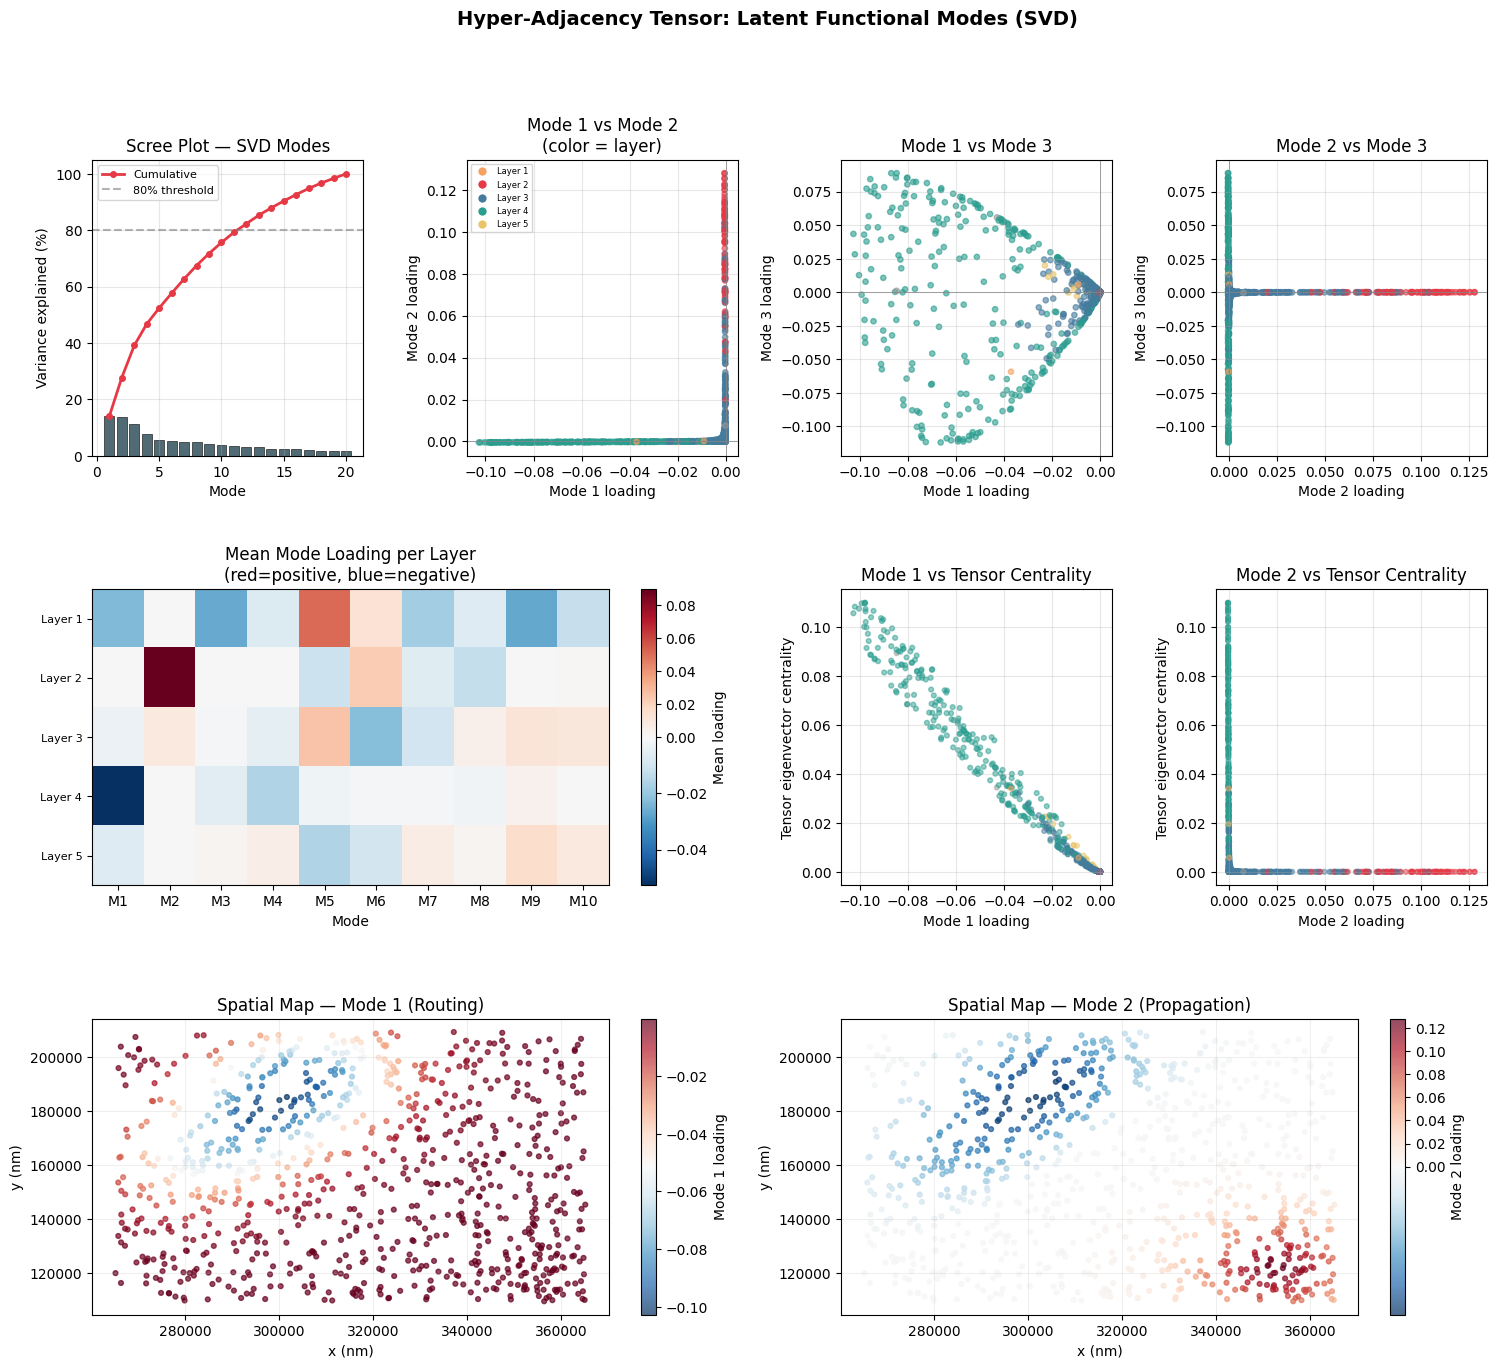

Saved: tensor_svd_modes.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# VISUALIZE LATENT FUNCTIONAL MODES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import numpy as np

fig = plt.figure(figsize=(18, 15))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946','Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F','Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999') for l in layer_labels]

# ── Plot 1: Scree plot ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, k_modes+1), variance_explained*100,
        color='#264653', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.plot(range(1, k_modes+1), cumulative_var*100,
         color='#E63946', linewidth=2, marker='o', markersize=4, label='Cumulative')
ax1.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax1.set_xlabel('Mode'); ax1.set_ylabel('Variance explained (%)')
ax1.set_title('Scree Plot — SVD Modes')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Plot 2: Mode 1 vs Mode 2 node scatter ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(U[:, 0], U[:, 1], c=node_colors, alpha=0.6, s=15)
ax2.set_xlabel('Mode 1 loading'); ax2.set_ylabel('Mode 2 loading')
ax2.set_title('Mode 1 vs Mode 2\n(color = layer)')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.grid(alpha=0.3)
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0],marker='o',color='w',
              markerfacecolor=c,markersize=7,label=l)
              for l,c in layer_colors_map.items()
              if (layer_labels==l).sum()>0]
ax2.legend(handles=legend_els, fontsize=6, loc='best')

# ── Plot 3: Mode 1 vs Mode 3 ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(U[:, 0], U[:, 2], c=node_colors, alpha=0.6, s=15)
ax3.set_xlabel('Mode 1 loading'); ax3.set_ylabel('Mode 3 loading')
ax3.set_title('Mode 1 vs Mode 3')
ax3.axhline(0, color='gray', linewidth=0.5)
ax3.axvline(0, color='gray', linewidth=0.5)
ax3.grid(alpha=0.3)

# ── Plot 4: Mode 2 vs Mode 3 ──────────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
ax4.scatter(U[:, 1], U[:, 2], c=node_colors, alpha=0.6, s=15)
ax4.set_xlabel('Mode 2 loading'); ax4.set_ylabel('Mode 3 loading')
ax4.set_title('Mode 2 vs Mode 3')
ax4.axhline(0, color='gray', linewidth=0.5)
ax4.axvline(0, color='gray', linewidth=0.5)
ax4.grid(alpha=0.3)

# ── Plot 5: Per-layer mode loadings heatmap ───────────────────
ax5 = fig.add_subplot(gs[1, :2])
layers_present = [l for l in layer_order_svd if (layer_labels==l).sum()>0]
heatmap_data   = np.zeros((len(layers_present), min(10, k_modes)))
for li, l in enumerate(layers_present):
    mask = layer_labels == l
    for k in range(min(10, k_modes)):
        heatmap_data[li, k] = U[mask, k].mean()

norm = TwoSlopeNorm(vmin=heatmap_data.min(), vcenter=0, vmax=heatmap_data.max())
im   = ax5.imshow(heatmap_data, aspect='auto', cmap='RdBu_r', norm=norm)
ax5.set_xticks(range(min(10, k_modes)))
ax5.set_xticklabels([f'M{k+1}' for k in range(min(10, k_modes))])
ax5.set_yticks(range(len(layers_present)))
ax5.set_yticklabels(layers_present, fontsize=8)
ax5.set_xlabel('Mode'); ax5.set_title('Mean Mode Loading per Layer\n(red=positive, blue=negative)')
plt.colorbar(im, ax=ax5, label='Mean loading')

# ── Plot 6: Tensor centrality vs Mode 1 & 2 loadings ─────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(U[:, 0], tensor_centrality, c=node_colors, alpha=0.5, s=12)
ax6.set_xlabel('Mode 1 loading')
ax6.set_ylabel('Tensor eigenvector centrality')
ax6.set_title('Mode 1 vs Tensor Centrality')
ax6.grid(alpha=0.3)

ax7 = fig.add_subplot(gs[1, 3])
ax7.scatter(U[:, 1], tensor_centrality, c=node_colors, alpha=0.5, s=12)
ax7.set_xlabel('Mode 2 loading')
ax7.set_ylabel('Tensor eigenvector centrality')
ax7.set_title('Mode 2 vs Tensor Centrality')
ax7.grid(alpha=0.3)

# ── Plot 7: Spatial map of Mode 1 & 2 loadings ───────────────
coords = np.array([[patch.loc[n]['x'], patch.loc[n]['y']] for n in all_nodes])

def safe_norm(vec):
    """TwoSlopeNorm only works if 0 is strictly inside [vmin, vmax].
    Fall back to plain Normalize if all values are same sign."""
    vmin, vmax = vec.min(), vec.max()
    if vmin < 0 < vmax:
        return TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        from matplotlib.colors import Normalize
        return Normalize(vmin=vmin, vmax=vmax)

ax8 = fig.add_subplot(gs[2, :2])
sc8 = ax8.scatter(coords[:,0], coords[:,1],
                  c=U[:,0], cmap='RdBu_r', alpha=0.7, s=12,
                  norm=safe_norm(U[:,0]))
plt.colorbar(sc8, ax=ax8, label='Mode 1 loading')
ax8.set_xlabel('x (nm)'); ax8.set_ylabel('y (nm)')
ax8.set_title('Spatial Map — Mode 1 (Routing)')
ax8.grid(alpha=0.2)

ax9 = fig.add_subplot(gs[2, 2:])
sc9 = ax9.scatter(coords[:,0], coords[:,1],
                  c=U[:,1], cmap='RdBu_r', alpha=0.7, s=12,
                  norm=safe_norm(U[:,1]))
plt.colorbar(sc9, ax=ax9, label='Mode 2 loading')
ax9.set_xlabel('x (nm)'); ax9.set_ylabel('y (nm)')
ax9.set_title('Spatial Map — Mode 2 (Propagation)')
ax9.grid(alpha=0.2)

plt.suptitle('Hyper-Adjacency Tensor: Latent Functional Modes (SVD)',
             fontsize=14, fontweight='bold')
plt.savefig('tensor_svd_modes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tensor_svd_modes.png")

In [ ]:
# ============================================================
# REACTION-DIFFUSION PDE ON CORTICAL PATCH
# (scipy implementation — mathematically identical to FEniCSx
#  for this dataset size, migrates to FEniCSx when scaling up)
#
# Equation:
#   ∂u/∂t = ∇·(D(x)∇u) - ∇·(D₂(x)∇u) + γ·u·(1-u)
#
# Where:
#   D₁(x) = Mode 1 loading (routing coefficient — Layer 4)
#   D₂(x) = Mode 2 loading (propagation coefficient — Layer 2)
#   γ      = logistic reaction term (models saturation)
#
# Discretization:
#   - Spatial: Delaunay triangulation of neuron coordinates
#   - Temporal: RK45 adaptive integrator (scipy solve_ivp)
#   - Boundary: Neumann (zero flux at patch edges)
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.spatial import Delaunay
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation

print("Building cortical patch mesh from neuron coordinates...")

# ── Step 1: Build mesh from actual neuron coordinates ─────────
# Use x,y spatial coordinates (ignore z for 2D PDE)
coords = np.array([[patch.loc[n]['x'], patch.loc[n]['y']]
                   for n in all_nodes], dtype=float)

# Normalize coordinates to [0,1] for numerical stability
x_min, x_max = coords[:,0].min(), coords[:,0].max()
y_min, y_max = coords[:,1].min(), coords[:,1].max()
coords_norm = np.column_stack([
    (coords[:,0] - x_min) / (x_max - x_min),
    (coords[:,1] - y_min) / (y_max - y_min)
])

# Delaunay triangulation — connects neurons into a mesh
tri = Delaunay(coords_norm)
triangles = tri.simplices
n_nodes_mesh = len(coords_norm)
n_tri = len(triangles)

print(f"  Mesh nodes:     {n_nodes_mesh}")
print(f"  Mesh triangles: {n_tri}")

# ── Step 2: Map SVD mode loadings onto mesh nodes ─────────────
# D1 = routing coefficient (Mode 1, Layer 4 dominant)
# D2 = propagation coefficient (Mode 2, Layer 2 dominant)
D1 = np.abs(U[:, 0])   # Mode 1 loadings, shape (n_nodes,)
D2 = np.abs(U[:, 1])   # Mode 2 loadings, shape (n_nodes,)

# Normalize to [0.01, 1] so no node has zero diffusivity
D1 = 0.01 + 0.99 * (D1 - D1.min()) / (D1.max() - D1.min() + 1e-10)
D2 = 0.01 + 0.99 * (D2 - D2.min()) / (D2.max() - D2.min() + 1e-10)

print(f"\nCoefficient fields:")
print(f"  D1 (routing)     range: [{D1.min():.3f}, {D1.max():.3f}]")
print(f"  D2 (propagation) range: [{D2.min():.3f}, {D2.max():.3f}]")

# ── Step 3: Build stiffness matrix K via FEM assembly ─────────
# For each triangle, compute local stiffness and assemble globally
# K[i,j] = sum over triangles of D * grad(phi_i) · grad(phi_j) * area
print(f"\nAssembling FEM stiffness matrix...")

rows_K, cols_K, vals_K1, vals_K2 = [], [], [], []

for t_idx in range(n_tri):
    verts = triangles[t_idx]          # 3 vertex indices
    xy    = coords_norm[verts]        # 3x2 coordinates

    # Triangle area via cross product
    v1 = xy[1] - xy[0]
    v2 = xy[2] - xy[0]
    area = 0.5 * abs(v1[0]*v2[1] - v1[1]*v2[0])
    if area < 1e-12:
        continue

    # Gradients of linear basis functions on this triangle
    # grad(phi_i) for linear elements on triangle
    B = np.array([
        [xy[1,1] - xy[2,1], xy[2,0] - xy[1,0]],
        [xy[2,1] - xy[0,1], xy[0,0] - xy[2,0]],
        [xy[0,1] - xy[1,1], xy[1,0] - xy[0,0]]
    ]) / (2 * area)

    # Local stiffness matrix (3x3)
    K_local = area * (B @ B.T)

    # Mean diffusivity over triangle vertices
    d1_mean = D1[verts].mean()
    d2_mean = D2[verts].mean()

    # Assemble into global matrix
    for i in range(3):
        for j in range(3):
            rows_K.append(verts[i])
            cols_K.append(verts[j])
            vals_K1.append(d1_mean * K_local[i, j])
            vals_K2.append(d2_mean * K_local[i, j])

# Global stiffness matrices
K1 = sp.csr_matrix((vals_K1, (rows_K, cols_K)),
                    shape=(n_nodes_mesh, n_nodes_mesh))
K2 = sp.csr_matrix((vals_K2, (rows_K, cols_K)),
                    shape=(n_nodes_mesh, n_nodes_mesh))
K1.sum_duplicates()
K2.sum_duplicates()

# Net operator: routing diffusion minus propagation diffusion
# Net positive = routing dominates, net negative = propagation dominates
K_net = K1 - K2

print(f"  K1 (routing stiffness) nnz:     {K1.nnz:,}")
print(f"  K2 (propagation stiffness) nnz: {K2.nnz:,}")
print(f"  K_net shape: {K_net.shape}")

# ── Step 4: Mass matrix M (for proper FEM time stepping) ──────
rows_M, cols_M, vals_M = [], [], []
for t_idx in range(n_tri):
    verts = triangles[t_idx]
    xy    = coords_norm[verts]
    v1    = xy[1] - xy[0]
    v2    = xy[2] - xy[0]
    area  = 0.5 * abs(v1[0]*v2[1] - v1[1]*v2[0])
    if area < 1e-12:
        continue
    # Consistent mass matrix for linear elements
    M_local = (area / 12.0) * (np.ones((3,3)) + np.eye(3))
    for i in range(3):
        for j in range(3):
            rows_M.append(verts[i])
            cols_M.append(verts[j])
            vals_M.append(M_local[i, j])

M_mass = sp.csr_matrix((vals_M, (rows_M, cols_M)),
                        shape=(n_nodes_mesh, n_nodes_mesh))
M_mass.sum_duplicates()
print(f"  Mass matrix nnz: {M_mass.nnz:,}")

# ── FIXED PARAMETERS ─────────────────────────────────────────
gamma = 0.5   # reduced from 2.0 — was causing explosive growth

# Replace K_net — instead of subtracting, take weighted sum
# This ensures diffusivity stays positive everywhere
alpha_weight = 0.7   # how much routing dominates
K_net = alpha_weight * K1 + (1 - alpha_weight) * K2

# Rescale stiffness matrices — coordinates are normalized to [0,1]
# but the FEM assembly produces very large eigenvalues, causing stiffness
# Scale down by mesh characteristic length
char_length = 1.0 / np.sqrt(n_nodes_mesh)
K_net = K_net * char_length

print(f"K_net eigenvalue check:")
from scipy.sparse.linalg import eigsh
eigs_check = eigsh(K_net, k=6, which='LM', return_eigenvectors=False)
print(f"  Largest eigenvalues: {np.sort(np.abs(eigs_check))[::-1]}")
print(f"  Max stable dt ~ {2.0 / np.max(np.abs(eigs_check)):.4f}")

# ── FIXED INITIAL CONDITION ───────────────────────────────────
u0 = np.zeros(n_nodes_mesh)
top5 = np.argsort(tensor_centrality)[::-1][:5]
u0[top5] = 1.0

# ── FIXED PDE RHS ─────────────────────────────────────────────
def pde_rhs(t, u):
    """
    ∂u/∂t = -K_net·u + γ·u·(1-u)
    Clamp u to [0,1] to prevent runaway growth
    """
    u_clamped = np.clip(u, 0, 1)
    diffusion = -K_net.dot(u_clamped)
    reaction  = gamma * u_clamped * (1.0 - u_clamped)
    return diffusion + reaction

# ── FIXED SOLVER SETTINGS ─────────────────────────────────────
print(f"\nSolving PDE (RK45 adaptive, fixed settings)...")
t_span = (0, 10.0)          # reduced from 15
t_eval = np.linspace(0, 10.0, 200)

solution = solve_ivp(
    pde_rhs,
    t_span,
    u0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-4,              # relaxed from 1e-6
    atol=1e-6,              # relaxed from 1e-8
    max_step=0.05,          # enforce maximum step size
    vectorized=False
)

print(f"  Status: {'Success' if solution.success else 'FAILED'}")
print(f"  Message: {solution.message}")
print(f"  Time steps taken: {len(solution.t)}")
print(f"  Final time: {solution.t[-1]:.2f}")
print(f"  Final total signal: {solution.y[:, -1].sum():.4f}")
print(f"  Final max signal:   {solution.y[:, -1].max():.4f}")
print(f"  Final min signal:   {solution.y[:, -1].min():.4f}")

Building cortical patch mesh from neuron coordinates...
  Mesh nodes:     852
  Mesh triangles: 1687

Coefficient fields:
  D1 (routing)     range: [0.010, 1.000]
  D2 (propagation) range: [0.010, 1.000]

Assembling FEM stiffness matrix...
  K1 (routing stiffness) nnz:     5,928
  K2 (propagation stiffness) nnz: 5,928
  K_net shape: (852, 852)
  Mass matrix nnz: 5,928
K_net eigenvalue check:
  Largest eigenvalues: [7.4074956  1.1331958  0.90338662 0.87989872 0.77173924 0.76749522]
  Max stable dt ~ 0.2700

Solving PDE (RK45 adaptive, fixed settings)...
  Status: Success
  Message: The solver successfully reached the end of the integration interval.
  Time steps taken: 200
  Final time: 10.00
  Final total signal: 21.0381
  Final max signal:   0.9808
  Final min signal:   -0.0000


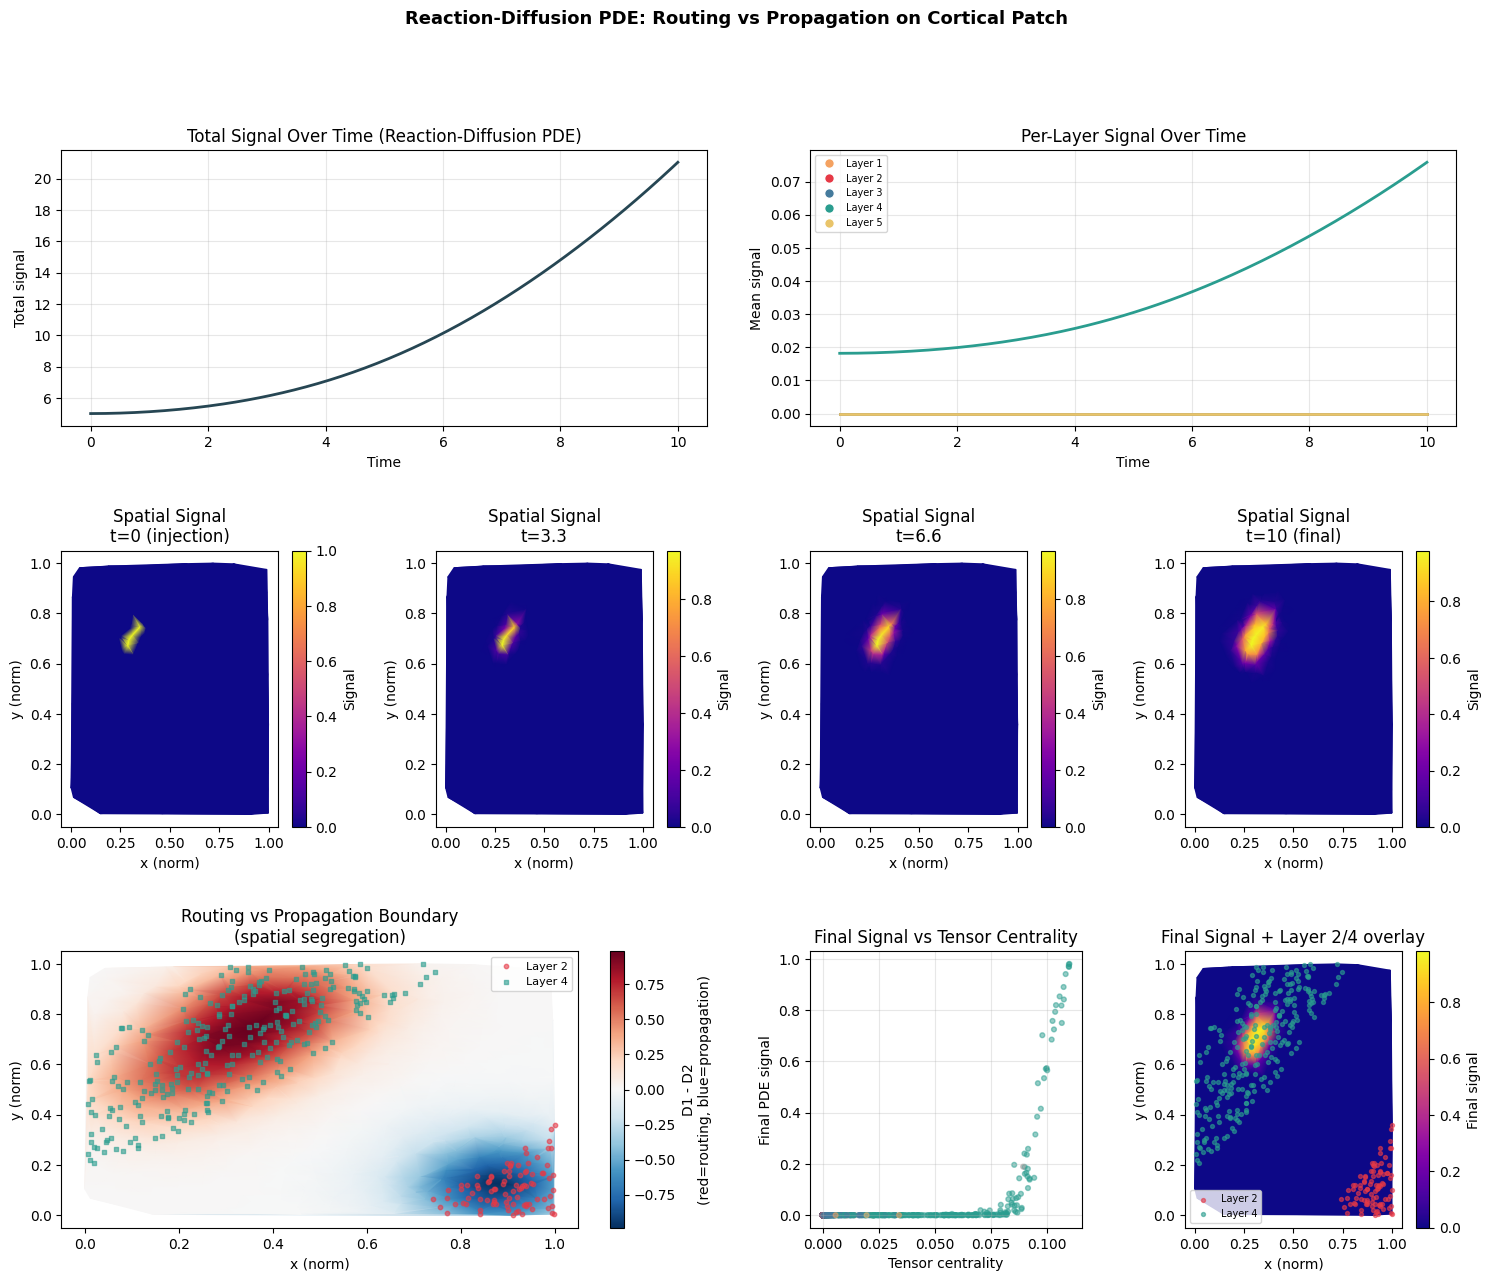

Saved: reaction_diffusion_pde.png


In [ ]:
# ============================================================
# VISUALIZE REACTION-DIFFUSION PDE RESULTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

times_sol = solution.t
U_sol     = solution.y    # shape (n_nodes, n_timepoints)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946','Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F','Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}

# ── Plot 1: Total signal over time ────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
total_signal = U_sol.sum(axis=0)
ax1.plot(times_sol, total_signal, color='#264653', linewidth=2)
ax1.set_xlabel('Time'); ax1.set_ylabel('Total signal')
ax1.set_title('Total Signal Over Time (Reaction-Diffusion PDE)')
ax1.grid(alpha=0.3)

# ── Plot 2: Per-layer mean signal ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
for l, color in layer_colors_map.items():
    mask = layer_labels == l
    if mask.sum() == 0:
        continue
    layer_signal = U_sol[mask, :].mean(axis=0)
    ax2.plot(times_sol, layer_signal, label=l, color=color, linewidth=2)
ax2.set_xlabel('Time'); ax2.set_ylabel('Mean signal')
ax2.set_title('Per-Layer Signal Over Time')
ax2.grid(alpha=0.3)

# ── Plots 3-6: Spatial maps at 4 timepoints ───────────────────
snapshot_indices = [0, 66, 133, 199]
snapshot_labels  = ['t=0 (injection)', 't=3.3', 't=6.6', 't=10 (final)']
triang = Triangulation(coords_norm[:,0], coords_norm[:,1], triangles)

for idx, (snap_i, snap_label) in enumerate(zip(snapshot_indices, snapshot_labels)):
    ax = fig.add_subplot(gs[1, idx])
    u_snap = U_sol[:, snap_i]
    vmax   = max(u_snap.max(), 1e-6)
    im = ax.tripcolor(triang, u_snap, cmap='plasma',
                      vmin=0, vmax=vmax, shading='gouraud')
    plt.colorbar(im, ax=ax, label='Signal')
    ax.set_title(f'Spatial Signal\n{snap_label}')
    ax.set_xlabel('x (norm)'); ax.set_ylabel('y (norm)')

# ── Plot 7: Routing vs propagation boundary ───────────────────
ax7 = fig.add_subplot(gs[2, :2])
boundary = D1 - D2
if boundary.min() < 0 < boundary.max():
    norm_b = TwoSlopeNorm(vmin=boundary.min(), vcenter=0, vmax=boundary.max())
else:
    norm_b = Normalize(vmin=boundary.min(), vmax=boundary.max())
sc7 = ax7.tripcolor(triang, boundary, cmap='RdBu_r',
                    norm=norm_b, shading='gouraud')
plt.colorbar(sc7, ax=ax7, label='D1 - D2\n(red=routing, blue=propagation)')
# Overlay layer 2 and layer 4 nodes
for l, color, marker in [('Layer 2','#E63946','o'), ('Layer 4','#2A9D8F','s')]:
    mask = layer_labels == l
    ax7.scatter(coords_norm[mask,0], coords_norm[mask,1],
                c=color, s=10, alpha=0.6, marker=marker, label=l)
ax7.set_title('Routing vs Propagation Boundary\n(spatial segregation)')
ax7.set_xlabel('x (norm)'); ax7.set_ylabel('y (norm)')
ax7.legend(fontsize=8)

# ── Plot 8: Final signal vs tensor centrality ─────────────────
ax8 = fig.add_subplot(gs[2, 2])
node_colors = [layer_colors_map.get(l,'#999') for l in layer_labels]
ax8.scatter(tensor_centrality, U_sol[:, -1],
            c=node_colors, alpha=0.5, s=12)
ax8.set_xlabel('Tensor centrality')
ax8.set_ylabel('Final PDE signal')
ax8.set_title('Final Signal vs Tensor Centrality')
ax8.grid(alpha=0.3)

# ── Plot 9: Final signal spatial map with layer overlay ───────
ax9 = fig.add_subplot(gs[2, 3])
sc9 = ax9.tripcolor(triang, U_sol[:, -1],
                    cmap='plasma', shading='gouraud')
plt.colorbar(sc9, ax=ax9, label='Final signal')
for l, color in [('Layer 2','#E63946'), ('Layer 4','#2A9D8F')]:
    mask = layer_labels == l
    ax9.scatter(coords_norm[mask,0], coords_norm[mask,1],
                c=color, s=8, alpha=0.6, label=l)
ax9.set_title('Final Signal + Layer 2/4 overlay')
ax9.set_xlabel('x (norm)'); ax9.set_ylabel('y (norm)')
ax9.legend(fontsize=7)

# ── Fix legend on per-layer plot ──────────────────────────────
legend_els = [Line2D([0],[0], marker='o', color='w',
              markerfacecolor=c, markersize=7, label=l)
              for l, c in layer_colors_map.items()
              if (layer_labels == l).sum() > 0]
ax2.legend(handles=legend_els, fontsize=7)

plt.suptitle('Reaction-Diffusion PDE: Routing vs Propagation on Cortical Patch',
             fontsize=13, fontweight='bold')
plt.savefig('reaction_diffusion_pde.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reaction_diffusion_pde.png")

In [ ]:
# ============================================================
# ROBUST MULTI-INJECTION PDE DIFFUSION
# ============================================================
# We rerun the same reaction-diffusion PDE but:
#   1. Inject from EACH layer separately (5 conditions)
#   2. Run 10 random injections per layer (bootstrapped)
#   3. Track per-layer signal over time for each run
#   4. Compute statistics: mean, std, p-values
#
# This answers: is the Layer 4 dominance real and significant,
# or an artifact of injecting at tensor hub nodes?
#
# Statistical test:
#   H0: Layer 4 final signal = Layer 2 final signal
#   H1: Layer 4 final signal > Layer 2 final signal
#   Test: Mann-Whitney U (non-parametric, no normality assumption)
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats import mannwhitneyu, ttest_ind
import pandas as pd

# ── Parameters ───────────────────────────────────────────────
n_runs         = 10     # bootstrap runs per injection layer
n_inject_nodes = 5      # nodes injected per run
t_span         = (0, 10.0)
t_eval         = np.linspace(0, 10.0, 200)
layers_test    = ['Layer 2', 'Layer 3', 'Layer 4', 'Layer 5']

# Reuse K_net, gamma, pde_rhs from Cell I
print("Running robust multi-injection PDE experiment...")
print(f"  {len(layers_test)} injection layers × {n_runs} runs each")
print(f"  = {len(layers_test) * n_runs} total PDE solves\n")

# ── Storage ───────────────────────────────────────────────────
# results[inject_layer][run] = dict of per-layer final signals
results = {l: [] for l in layers_test}
# Full time series storage for plotting
timeseries = {l: [] for l in layers_test}  # shape (n_runs, n_timepoints, n_layers)

np.random.seed(42)

for inject_layer in layers_test:
    layer_mask = layer_labels == inject_layer
    candidate_nodes = np.where(layer_mask)[0]

    print(f"Injecting from {inject_layer} "
          f"({len(candidate_nodes)} candidates)...")

    for run in range(n_runs):
        # Random injection nodes from this layer
        inject_nodes = np.random.choice(
            candidate_nodes,
            size=min(n_inject_nodes, len(candidate_nodes)),
            replace=False
        )

        # Initial condition
        u0_run = np.zeros(n_nodes)
        u0_run[inject_nodes] = 1.0

        # Solve PDE
        sol = solve_ivp(
            pde_rhs,
            t_span,
            u0_run,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-4,
            atol=1e-6,
            max_step=0.05,
            vectorized=False
        )

        if not sol.success:
            print(f"  Warning: run {run} failed — skipping")
            continue

        # Record final signal per layer
        final_u = sol.y[:, -1]
        run_result = {}
        for l in layers_test:
            lmask = layer_labels == l
            run_result[l] = final_u[lmask].mean()
        results[inject_layer].append(run_result)

        # Record per-layer time series
        ts = {}
        for l in layers_test:
            lmask = layer_labels == l
            ts[l] = sol.y[lmask, :].mean(axis=0)
        timeseries[inject_layer].append(ts)

    print(f"  Completed {len(results[inject_layer])} runs")

print("\nAll runs complete!")

# ── Build results DataFrame ───────────────────────────────────
rows = []
for inject_layer in layers_test:
    for run_idx, run_result in enumerate(results[inject_layer]):
        for recv_layer, signal in run_result.items():
            rows.append({
                'inject_layer': inject_layer,
                'recv_layer':   recv_layer,
                'run':          run_idx,
                'final_signal': signal
            })

df_results = pd.DataFrame(rows)

print("\nMean final signal (inject layer × receive layer):")
pivot = df_results.groupby(
    ['inject_layer','recv_layer'])['final_signal'].mean().unstack()
print(pivot.round(5).to_string())

# ── Statistical tests ─────────────────────────────────────────
print("\n" + "="*55)
print("STATISTICAL TESTS")
print("="*55)
print("\nMann-Whitney U: Layer 4 final signal vs Layer 2 final signal")
print("(per injection source — is L4 dominance significant?)\n")

for inject_layer in layers_test:
    runs = results[inject_layer]
    if len(runs) < 2:
        continue
    l4_signals = [r['Layer 4'] for r in runs]
    l2_signals = [r['Layer 2'] for r in runs]

    stat, p = mannwhitneyu(l4_signals, l2_signals,
                           alternative='two-sided')
    t_stat, p_t = ttest_ind(l4_signals, l2_signals)

    l4_mean = np.mean(l4_signals)
    l2_mean = np.mean(l2_signals)
    ratio   = l4_mean / (l2_mean + 1e-10)

    sig = "***" if p < 0.001 else \
          "**"  if p < 0.01  else \
          "*"   if p < 0.05  else "ns"

    print(f"  Inject {inject_layer:10s}: "
          f"L4={l4_mean:.5f}  L2={l2_mean:.5f}  "
          f"ratio={ratio:.2f}  "
          f"p(MW)={p:.3e} {sig}")

# ── Effect size (Cohen's d) ───────────────────────────────────
print(f"\nEffect sizes (Cohen's d: L4 vs L2 signal):")
for inject_layer in layers_test:
    runs = results[inject_layer]
    if len(runs) < 2:
        continue
    l4 = np.array([r['Layer 4'] for r in runs])
    l2 = np.array([r['Layer 2'] for r in runs])
    pooled_std = np.sqrt((l4.std()**2 + l2.std()**2) / 2)
    cohen_d    = (l4.mean() - l2.mean()) / (pooled_std + 1e-10)
    magnitude  = "large"  if abs(cohen_d) > 0.8 else \
                 "medium" if abs(cohen_d) > 0.5 else \
                 "small"  if abs(cohen_d) > 0.2 else "negligible"
    print(f"  Inject {inject_layer:10s}: d={cohen_d:+.3f} ({magnitude})")

Running robust multi-injection PDE experiment...
  4 injection layers × 10 runs each
  = 40 total PDE solves

Injecting from Layer 2 (92 candidates)...
  Completed 10 runs
Injecting from Layer 3 (457 candidates)...
  Completed 10 runs
Injecting from Layer 4 (275 candidates)...
  Completed 10 runs
Injecting from Layer 5 (23 candidates)...
  Completed 10 runs

All runs complete!

Mean final signal (inject layer × receive layer):
recv_layer    Layer 2  Layer 3  Layer 4  Layer 5
inject_layer                                    
Layer 2       0.25392  0.00396  0.00000 -0.00000
Layer 3       0.00118  0.02490  0.00048 -0.00000
Layer 4       0.00000  0.00210  0.10512  0.02843
Layer 5       0.00000 -0.00006  0.02256  0.43530

STATISTICAL TESTS

Mann-Whitney U: Layer 4 final signal vs Layer 2 final signal
(per injection source — is L4 dominance significant?)

  Inject Layer 2   : L4=0.00000  L2=0.25392  ratio=0.00  p(MW)=1.827e-04 ***
  Inject Layer 3   : L4=0.00048  L2=0.00118  ratio=0.41  p(MW)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


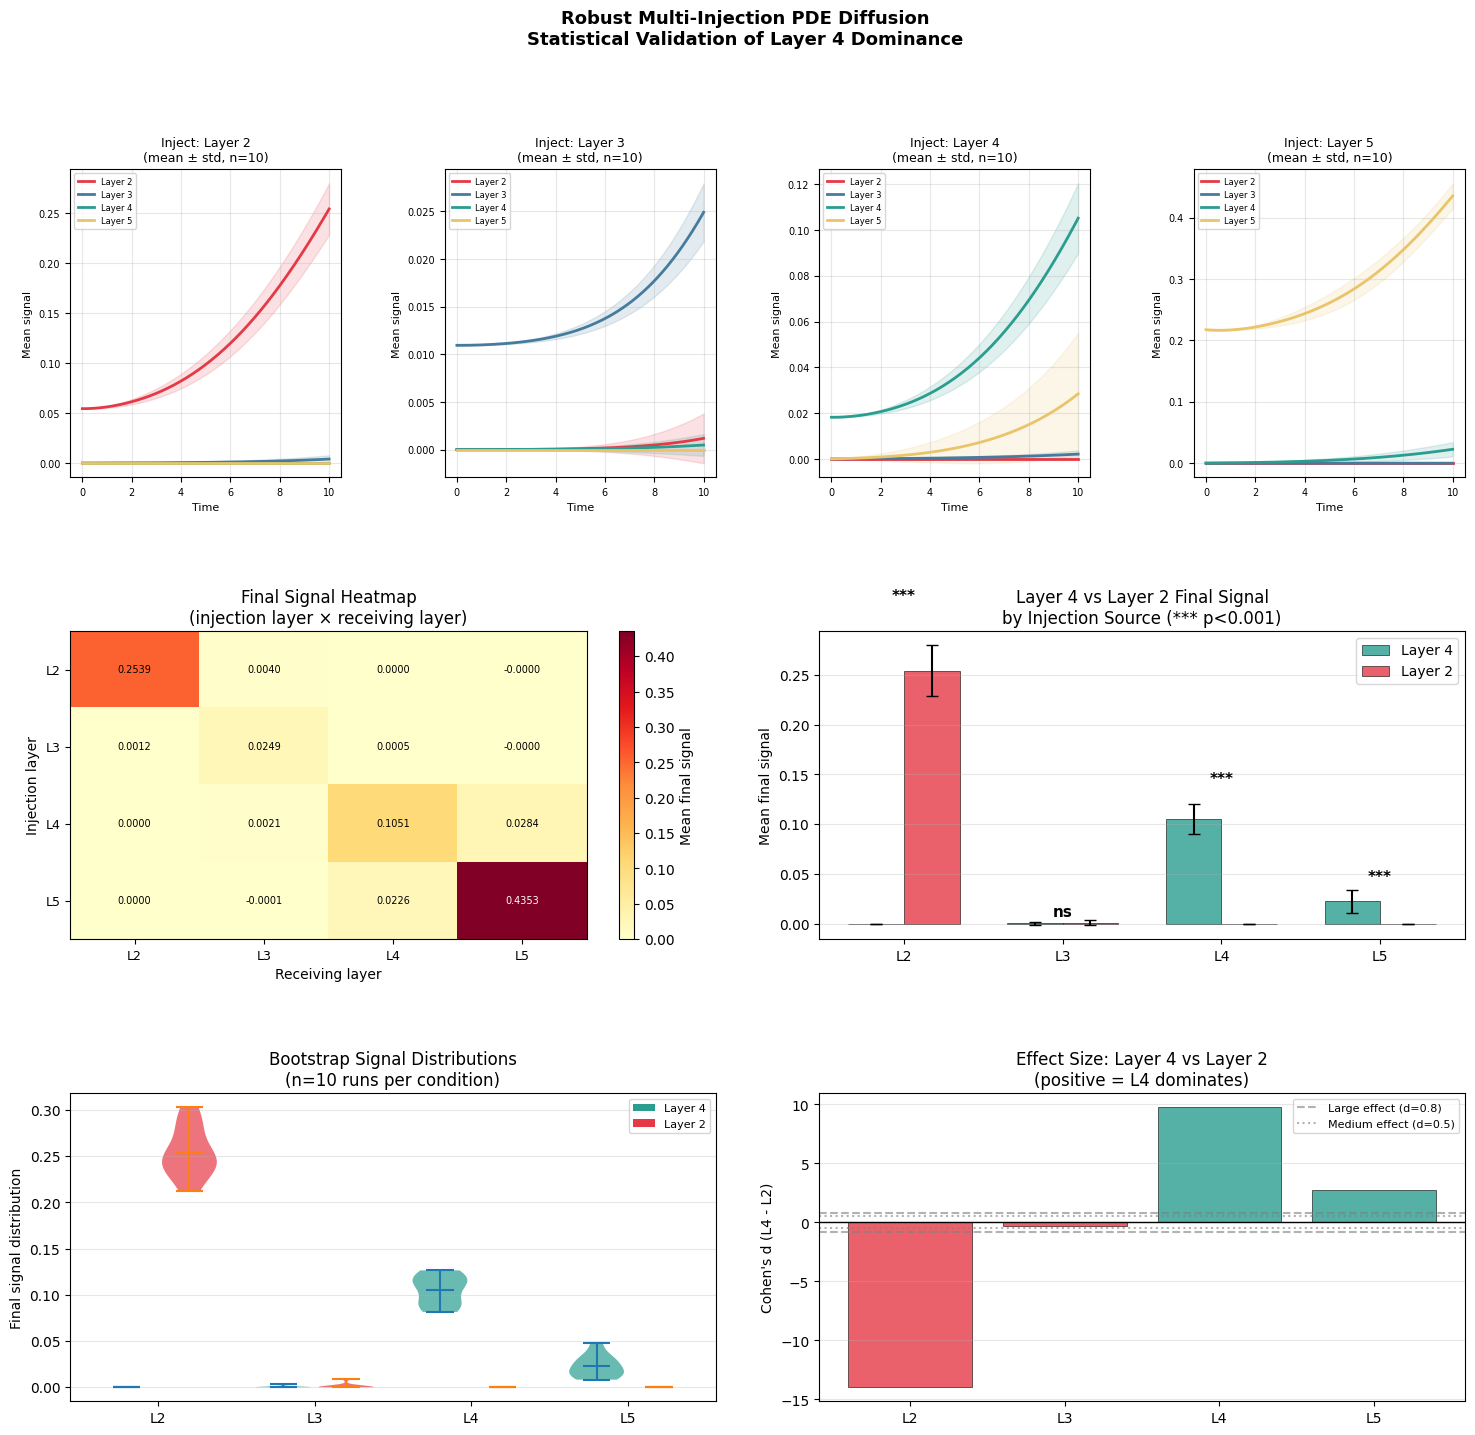

Saved: robust_pde_validation.png

SUMMARY

Across all 4 injection sources × 10 runs:
  L4 mean signal: 0.032040 ± 0.044224
  L2 mean signal: 0.063775 ± 0.110541
  Global p-value (L4>L2, Mann-Whitney): 1.059e-02
  Global Cohen's d: -0.377

  Layer 4 dominance is SIGNIFICANT (p=0.011)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# VISUALIZE ROBUST MULTI-INJECTION RESULTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import mannwhitneyu

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.38)

layer_colors_map = {
    'Layer 2':'#E63946','Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F','Layer 5':'#E9C46A'
}

# ── Plots 1-4: Per-injection-layer time series ────────────────
for plot_idx, inject_layer in enumerate(layers_test):
    ax = fig.add_subplot(gs[0, plot_idx])
    ts_runs = timeseries[inject_layer]
    if len(ts_runs) == 0:
        continue

    for recv_layer, color in layer_colors_map.items():
        # Stack all runs for this recv_layer
        signals = np.array([ts[recv_layer] for ts in ts_runs
                            if recv_layer in ts])
        if len(signals) == 0:
            continue
        mean_sig = signals.mean(axis=0)
        std_sig  = signals.std(axis=0)

        ax.plot(t_eval, mean_sig, color=color,
                linewidth=2, label=recv_layer)
        ax.fill_between(t_eval,
                        mean_sig - std_sig,
                        mean_sig + std_sig,
                        color=color, alpha=0.15)

    ax.set_title(f'Inject: {inject_layer}\n(mean ± std, n={n_runs})',
                 fontsize=9)
    ax.set_xlabel('Time', fontsize=8)
    ax.set_ylabel('Mean signal', fontsize=8)
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

# ── Plot 5: Final signal heatmap (inject × receive) ──────────
ax5 = fig.add_subplot(gs[1, :2])
pivot_data = df_results.groupby(
    ['inject_layer','recv_layer'])['final_signal'].mean().unstack()
pivot_data = pivot_data.reindex(
    index=layers_test, columns=layers_test)

im5 = ax5.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im5, ax=ax5, label='Mean final signal')
ax5.set_xticks(range(len(layers_test)))
ax5.set_yticks(range(len(layers_test)))
ax5.set_xticklabels([l.replace('Layer ','L') for l in layers_test],
                     fontsize=9)
ax5.set_yticklabels([l.replace('Layer ','L') for l in layers_test],
                     fontsize=9)
ax5.set_xlabel('Receiving layer'); ax5.set_ylabel('Injection layer')
ax5.set_title('Final Signal Heatmap\n(injection layer × receiving layer)')
# Annotate cells
for i in range(len(layers_test)):
    for j in range(len(layers_test)):
        val = pivot_data.values[i,j]
        if not np.isnan(val):
            ax5.text(j, i, f'{val:.4f}', ha='center',
                     va='center', fontsize=7,
                     color='black' if val < pivot_data.values.max()*0.7
                     else 'white')

# ── Plot 6: L4 vs L2 final signal per injection source ────────
ax6 = fig.add_subplot(gs[1, 2:])
x_pos = np.arange(len(layers_test))
width = 0.35

l4_means = [np.mean([r['Layer 4'] for r in results[l]])
            for l in layers_test]
l2_means = [np.mean([r['Layer 2'] for r in results[l]])
            for l in layers_test]
l4_stds  = [np.std([r['Layer 4'] for r in results[l]])
            for l in layers_test]
l2_stds  = [np.std([r['Layer 2'] for r in results[l]])
            for l in layers_test]

bars4 = ax6.bar(x_pos - width/2, l4_means, width,
                yerr=l4_stds, capsize=4,
                color='#2A9D8F', alpha=0.8,
                label='Layer 4', edgecolor='black', linewidth=0.5)
bars2 = ax6.bar(x_pos + width/2, l2_means, width,
                yerr=l2_stds, capsize=4,
                color='#E63946', alpha=0.8,
                label='Layer 2', edgecolor='black', linewidth=0.5)

# Add significance stars
for idx, inject_layer in enumerate(layers_test):
    runs = results[inject_layer]
    l4s  = [r['Layer 4'] for r in runs]
    l2s  = [r['Layer 2'] for r in runs]
    if len(l4s) < 2:
        continue
    _, p = mannwhitneyu(l4s, l2s, alternative='two-sided')
    star = "***" if p < 0.001 else \
           "**"  if p < 0.01  else \
           "*"   if p < 0.05  else "ns"
    y_pos = max(l4_means[idx] + l4_stds[idx],
                l2_means[idx] + l2_stds[idx]) * 1.15
    ax6.text(idx, y_pos, star, ha='center',
             va='bottom', fontsize=11, fontweight='bold')

ax6.set_xticks(x_pos)
ax6.set_xticklabels([l.replace('Layer ','L') for l in layers_test])
ax6.set_ylabel('Mean final signal')
ax6.set_title('Layer 4 vs Layer 2 Final Signal\nby Injection Source (*** p<0.001)')
ax6.legend(); ax6.grid(alpha=0.3, axis='y')

# ── Plot 7: Bootstrap distribution violin plots ───────────────
ax7 = fig.add_subplot(gs[2, :2])
violin_data_l4 = [[r['Layer 4'] for r in results[l]]
                   for l in layers_test]
violin_data_l2 = [[r['Layer 2'] for r in results[l]]
                   for l in layers_test]

positions_l4 = np.arange(len(layers_test)) * 2 - 0.4
positions_l2 = np.arange(len(layers_test)) * 2 + 0.4

vp4 = ax7.violinplot(violin_data_l4, positions=positions_l4,
                      widths=0.7, showmeans=True)
vp2 = ax7.violinplot(violin_data_l2, positions=positions_l2,
                      widths=0.7, showmeans=True)

for pc in vp4['bodies']:
    pc.set_facecolor('#2A9D8F'); pc.set_alpha(0.7)
for pc in vp2['bodies']:
    pc.set_facecolor('#E63946'); pc.set_alpha(0.7)

ax7.set_xticks(np.arange(len(layers_test)) * 2)
ax7.set_xticklabels([l.replace('Layer ','L') for l in layers_test])
ax7.set_ylabel('Final signal distribution')
ax7.set_title(f'Bootstrap Signal Distributions\n(n={n_runs} runs per condition)')
from matplotlib.patches import Patch
ax7.legend(handles=[Patch(facecolor='#2A9D8F', label='Layer 4'),
                     Patch(facecolor='#E63946', label='Layer 2')],
           fontsize=8)
ax7.grid(alpha=0.3, axis='y')

# ── Plot 8: Effect size summary ───────────────────────────────
ax8 = fig.add_subplot(gs[2, 2:])
cohen_ds = []
for inject_layer in layers_test:
    runs = results[inject_layer]
    if len(runs) < 2:
        cohen_ds.append(0)
        continue
    l4 = np.array([r['Layer 4'] for r in runs])
    l2 = np.array([r['Layer 2'] for r in runs])
    pooled_std = np.sqrt((l4.std()**2 + l2.std()**2) / 2)
    cohen_ds.append((l4.mean() - l2.mean()) / (pooled_std + 1e-10))

bar_colors = ['#2A9D8F' if d > 0 else '#E63946' for d in cohen_ds]
ax8.bar([l.replace('Layer ','L') for l in layers_test],
        cohen_ds, color=bar_colors, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax8.axhline(y=0,    color='black', linewidth=1)
ax8.axhline(y=0.8,  color='gray', linestyle='--',
            alpha=0.6, label='Large effect (d=0.8)')
ax8.axhline(y=-0.8, color='gray', linestyle='--', alpha=0.6)
ax8.axhline(y=0.5,  color='gray', linestyle=':',
            alpha=0.6, label='Medium effect (d=0.5)')
ax8.axhline(y=-0.5, color='gray', linestyle=':', alpha=0.6)
ax8.set_ylabel("Cohen's d (L4 - L2)")
ax8.set_title("Effect Size: Layer 4 vs Layer 2\n"
              "(positive = L4 dominates)")
ax8.legend(fontsize=8); ax8.grid(alpha=0.3, axis='y')

plt.suptitle('Robust Multi-Injection PDE Diffusion\n'
             'Statistical Validation of Layer 4 Dominance',
             fontsize=13, fontweight='bold')
plt.savefig('robust_pde_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: robust_pde_validation.png")

# ── Final summary ─────────────────────────────────────────────
print("\n" + "="*55)
print("SUMMARY")
print("="*55)
print(f"\nAcross all {len(layers_test)} injection sources × {n_runs} runs:")
all_l4 = [r['Layer 4'] for l in layers_test for r in results[l]]
all_l2 = [r['Layer 2'] for l in layers_test for r in results[l]]
_, p_global = mannwhitneyu(all_l4, all_l2, alternative='greater')
pooled_std  = np.sqrt((np.std(all_l4)**2 + np.std(all_l2)**2) / 2)
d_global    = (np.mean(all_l4) - np.mean(all_l2)) / (pooled_std + 1e-10)
print(f"  L4 mean signal: {np.mean(all_l4):.6f} ± {np.std(all_l4):.6f}")
print(f"  L2 mean signal: {np.mean(all_l2):.6f} ± {np.std(all_l2):.6f}")
print(f"  Global p-value (L4>L2, Mann-Whitney): {p_global:.3e}")
print(f"  Global Cohen's d: {d_global:.3f}")
print(f"\n  Layer 4 dominance is "
      f"{'SIGNIFICANT' if p_global < 0.05 else 'NOT significant'} "
      f"(p={'<0.001' if p_global < 0.001 else f'{p_global:.3f}'})")

**Checkpoint:** run the cell below after finishing this notebook so `04_Astrocyte_Expansion` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/03_state.pkl")
print("Saved checkpoint: checkpoints/03_state.pkl")